# AC209b Drug Protein Affinity Prediction
**Canvas Group**: Group #109  
**Group Members**: Andrew Jing, Awassada Ariyaphuttarat, Hoi Cheung, Sammy Mohamed

## Background & Motivation

Traditional drug discovery is a high-cost, high-failure process limited by the speed of physical "wet lab" screening. This project leverages Transfer Learning to bypass these limitations. By utilizing massive, pre-trained transformers like ProteinBERT and ChemBERTa, we translate the hidden biological and chemical grammars already learned from millions of sequences into a specific prediction of binding strength.

## The Problem Statement

We frame drug discovery as a high-dimensional regression task: Can we accurately predict the binding affinity between a drug and a protein by fusing pre-trained 1D sequential embeddings?


## Table of Contents

0. [Summary of MS2](#0-Summary-of-MS2)
1. [Setup & Imports](#1-setup--imports)
2. [Raw Data Loading](#2-raw-data-loading)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Preprocessing](#4-preprocessing)
5. [Summary of EDA and Preprocessing Findings](#5-summary-of-eda-and-preprocessing-findings)
6. [Encoders — ProteinBERT & ChemBERTa](#6-encoders)
7. [Kd Predictor](#7-pkd-predictor)
8. [Training & Evaluation](#8-training--evaluation)
9. [Summary of Results and Future Directions](#9-summary-of-results-and-future-directions)

# 0. Summary of MS2

#### Rescoping from Proposal

Dual-stream LSTM → ProteinBERT + ChemBERTa for better long-range dependency modeling

#### Key Insights from EDA

pKd = 5.0 artifact identified as assay ceiling (Kd = 10 μM) - removed from training 
Severe class imbalance: stratified splits 
ProteinBERT chosen over ESM-2: no hard sequence length cap (ESM-2 caps at 1022)

#### Issues Addressed

Inter-lab noise: no longer dropping high-SD pairs/averaging → keep all observations so model learns full pKd distribution
Visuals: added slide numbers; preset matplotlib font size for all figures

#### Constructed Preprocessing Pipeline

See preprocessing section below for details

## 1. Setup & Imports

In [1]:
import os

if "COLAB_RELEASE_TAG" in os.environ:
    #!pip install -q PyTDC
    #!pip install -q -U transformers huggingface_hub

    from google.colab import drive

    drive.mount("/content/drive")

    for name in ["data", "checkpoints"]:
        src = f"/content/drive/MyDrive/CS209b_project/{name}"
        if not os.path.exists(f"./{name}"):
            os.symlink(src, f"./{name}")


In [2]:
!pip3 install requests

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import sys
!{sys.executable} -m pip install PyTDC transformers rdkit tqdm scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached pytdc-1.1.15-py3-none-any.whl
  Using cached rdkit-2026.3.1-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (3.8 kB)
  Using cached accelerate-0.33.0-py3-none-any.whl.metadata (18 kB)
  Using cached datasets-2.19.2-py3-none-any.whl.metadata (19 kB)
  Using cached evaluate-0.4.2-py3-none-any.whl.metadata (9.3 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached transformers-4.50.3-py3-none-any.whl.metadata (39 kB)
  Using cached cellxgene_census-1.15.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached gget-0.30.3-py3-none-any.whl.metadata (8.4 kB)
  Using cached rdkit-2023.9.6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.9 kB)
  Using cached tiledbsoma-1.17.1-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (7.0 kB)
  Using cached tiledbsoma-1.11.4-cp311-cp311-manylin

In [6]:
import time
import hashlib
import warnings
import requests
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import transformers
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import AutoTokenizer, AutoModel
from tdc.multi_pred.dti import DTI
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import StratifiedShuffleSplit

try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, rdMolDescriptors

    RDKIT_AVAILABLE = True
except ImportError:
    print("RDKit not available — drug class section will be skipped")
    RDKIT_AVAILABLE = False


transformers.logging.set_verbosity_error()

warnings.filterwarnings("ignore")

DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Using device: {DEVICE}")

SEED = 42

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)


Using device: cuda


## 2. Raw Data Loading

Load BindingDB Kd from TDC, enriched with cached `Protein_Family` labels from `bindingdb_kd_with_proteinfamily.csv` (pre-computed via the UniProt REST API — see Section 3.7).

Columns after loading:
- `Drug_ID` — canonical drug identifier
- `Drug` — SMILES string of the small molecule
- `Target_ID` — UniProt accession
- `Target` — amino acid sequence of the protein
- `Y` — Kd binding affinity in nM (lower = stronger binding)
- `Protein_Family` — coarse family label from UniProt keyword matching

In [7]:
Path("./data").mkdir(exist_ok=True)

family_csv = Path("./data/bindingdb_kd_with_proteinfamily.csv")
raw_csv = Path("./data/bindingdb_kd.csv")

if family_csv.exists():
    df = pd.read_csv(family_csv)
    print(f"Loaded family-enriched dataset: {family_csv}")
elif raw_csv.exists():
    df = pd.read_csv(raw_csv)
    print(f"Loaded raw dataset: {raw_csv} (Protein_Family column will be missing)")
else:
    data = DTI(name="BindingDB_Kd")
    df = data.get_data()
    df.to_csv(raw_csv, index=False)
    print(f"Downloaded from TDC and saved to {raw_csv}")

size_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Shape: {df.shape}")
print(f"In-memory size: {size_mb:.1f} MB")
df.head()


Loaded family-enriched dataset: data/bindingdb_kd_with_proteinfamily.csv
Shape: (52274, 6)
In-memory size: 50.7 MB


,Drug_ID,Drug,Target_ID,Target,Y,Protein_Family
0,444607.0,Cc1ccc(CNS(=O)(=O)c2ccc(S(N)(=O)=O)s2)cc1,P00918,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKP...,0.46,GPCR
1,4316.0,COc1ccc(CNS(=O)(=O)c2ccc(S(N)(=O)=O)s2)cc1,P00918,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKP...,0.49,GPCR
2,4293.0,NS(=O)(=O)c1ccc(S(=O)(=O)NCc2cccs2)s1,P00918,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKP...,0.83,GPCR
3,1611.0,NS(=O)(=O)c1cc2c(s1)S(=O)(=O)N(Cc1cccs1)CC2O,P00918,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKP...,0.20,GPCR
4,1612.0,COc1ccc(N2CC(O)c3cc(S(N)(=O)=O)sc3S2(=O)=O)cc1,P00918,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKP...,0.16,GPCR


### 2.1 Missingness check

In [8]:
missing_summary = pd.DataFrame(
    {
        "n_missing": df.isna().sum(),
        "% missing": (df.isna().mean() * 100).round(3),
        "dtype": df.dtypes.astype(str),
    }
)
print(missing_summary)

# Critical columns — anything missing here means we drop the row
critical = ["Drug", "Target", "Y"]
n_critical_missing = df[critical].isna().any(axis=1).sum()
print(f"\nRows missing any critical field ({critical}): {n_critical_missing:,}")

if n_critical_missing > 0:
    print("Dropping rows with missing critical fields.")
    df = df.dropna(subset=critical).reset_index(drop=True)
    print(f"New shape: {df.shape}")
else:
    print("No missing data in critical columns — no rows dropped.")


                n_missing  % missing    dtype
Drug_ID                 0      0.000  float64
Drug                    0      0.000   object
Target_ID            4333      8.289   object
Target                  0      0.000   object
Y                       0      0.000  float64
Protein_Family       4333      8.289   object

Rows missing any critical field (['Drug', 'Target', 'Y']): 0
No missing data in critical columns — no rows dropped.


**Finding:**

Roughly ~8% of rows are missing `Target_ID` (the UniProt accession), but fortunately this is a supporting column. The `Target` amino acid sequence is always present, and we use the sequence (not the ID) as the protein identifier throughout the pipeline. We note this so that any downstream logic that needs to look proteins up by ID (e.g. for family assignment via UniProt) must first fall back to sequence-based matching or cope with the missing IDs explicitly.

Since there are no gaps in the fields we actually model, we don't need to impute for missingness.

## 3. Exploratory Data Analysis

### 3.1 Processing Kd

In [9]:
# Drop rows with Y == 0 (would produce infinite pKd) and compute pKd
n_zero = (df["Y"] == 0).sum()
if n_zero > 0:
    print(f"Dropping {n_zero} row(s) with Y == 0 (would produce infinite pKd)")
    df = df[df["Y"] != 0].copy()

df["pKd"] = -np.log10(df["Y"] / 1e9)
print(df["pKd"].describe())


Dropping 2 row(s) with Y == 0 (would produce infinite pKd)
count    52272.000000
mean         5.888650
std          1.394610
min          2.000000
25%          5.000000
50%          5.007228
75%          6.657577
max         15.000000
Name: pKd, dtype: float64


**Finding:**

The binding affinity values (Kd) span several orders of magnitude, so we apply a negative log10 transform to convert them to pKd values: `pKd = −log10(Kd / 1e9)`.

Higher pKd indicates stronger binding — a pKd of 9 corresponds to Kd = 1 nM, while a pKd of 5 corresponds to Kd = 10 μM.

### 3.2 Verifying Bijective ID Mappings

In [10]:
# ensure each protein is bijective with ID
protein_id_counts = df.groupby("Target")["Target_ID"].nunique()
conflicting_proteins = protein_id_counts[protein_id_counts > 1]
if len(conflicting_proteins) > 0:
    print("\nProteins with conflicting IDs:")
    print(conflicting_proteins)
else:
    print("\nNo proteins with conflicting IDs")
id_protein_counts = df.groupby("Target_ID")["Target"].nunique()
conflicting_protein_ids = id_protein_counts[id_protein_counts > 1]
if len(conflicting_protein_ids) > 0:
    print("\nIDs with conflicting protein sequences:")
    print(conflicting_protein_ids)
else:
    print("\nNo IDs with conflicting protein sequences")
print()

# ensure each drug is bijective with ID
drug_id_counts = df.groupby("Drug")["Drug_ID"].nunique()
conflicting_drugs = drug_id_counts[drug_id_counts > 1]
if len(conflicting_drugs) > 0:
    print("\nDrugs with conflicting IDs:")
    print(conflicting_drugs)
else:
    print("\nNo drugs with conflicting IDs")
id_drug_counts = df.groupby("Drug_ID")["Drug"].nunique()
conflicting_drug_ids = id_drug_counts[id_drug_counts > 1]
if len(conflicting_drug_ids) > 0:
    print("\nIDs with conflicting drug formulas:")
    print(conflicting_drug_ids)
else:
    print("\nNo IDs with conflicting drug formulas")
print()



Proteins with conflicting IDs:
Target
MADQLTEEQIAEFKEAFSLFDKDGDGTITTKELGTVMRSLGQNPTEAELQDMINEVDADGNGTIDFPEFLTMMARKMKDTDSEEEIREAFRVFDKDGNGYISAAELRHVMTNLGEKLTDEEVDEMIREADIDGDGQVNYEEFVQMMTAK                                                                                                                                                                                                                                                                    2
MTSVMSHEFQLATAETWPNPWPMYRALRDHDPVHHVVPPQRPEYDYYVLSRHADVWSAARDHQTFSSAQGLTVNYGELEMIGLHDTPPMVMQDPPVHTEFRKLVSRGFTPRQVETVEPTVRKFVVERLEKLRANGGGDIVTELFKPLPSMVVAHYLGVPEEDWTQFDGWTQAIVAANAVDGATTGALDAVGSMMAYFTGLIERRRTEPADDAISHLVAAGVGADGDTAGTLSILAFTFTMVTGGNDTVTGMLGGSMPLLHRRPDQRRLLLDDPEGIPDAVEELLRLTSPVQGLARTTTRDVTIGDTTIPAGRRVLLLYGSANRDERQYGPDAAELDVTRCPRNILTFSHGAHHCLGAAAARMQCRVALTELLARCPDFEVAESRIVWSGGSYVRRPLSVPFRVTS    2
Name: Target_ID, dtype: int64

No IDs with conflicting protein sequences


No drugs with conflicting IDs

IDs with conflicting drug formula

In [11]:
# count number of pairs in conflicted drug IDs
if len(conflicting_drug_ids) > 0:
    conflicted_drug_ids = df[df["Drug_ID"].isin(conflicting_drug_ids.index)][
        "Drug_ID"
    ].unique()
    num_conflicted_pairs = df[df["Drug_ID"].isin(conflicted_drug_ids)].shape[0]
    print(f"Number of pairs with conflicted drug IDs: {num_conflicted_pairs}")
else:
    print("No conflicted drug IDs, so 0 pairs affected")


Number of pairs with conflicted drug IDs: 1017


**Finding:**

It appears that the `Drug_ID` and `Target_ID` columns are not strictly bijective with their corresponding sequences (`Drug` and `Target`). We speculate that some drugs or proteins may be encoded slightly differently across labs e.g. isomers. Anyhow, we will use sequences for modelling, and will drop the ID columns to avoid confusion.

### 3.3 Distribution of Drug, Protein, and pKd values

We want to know what the distribution of drugs, proteins, and binding affinities looks like in the dataset. In protein and drug modelling, it is important to understand their structures in entirity. We will try to find embedders that allow for long sequences, and drop rather than truncate, any sequences that exceed the maximum length.

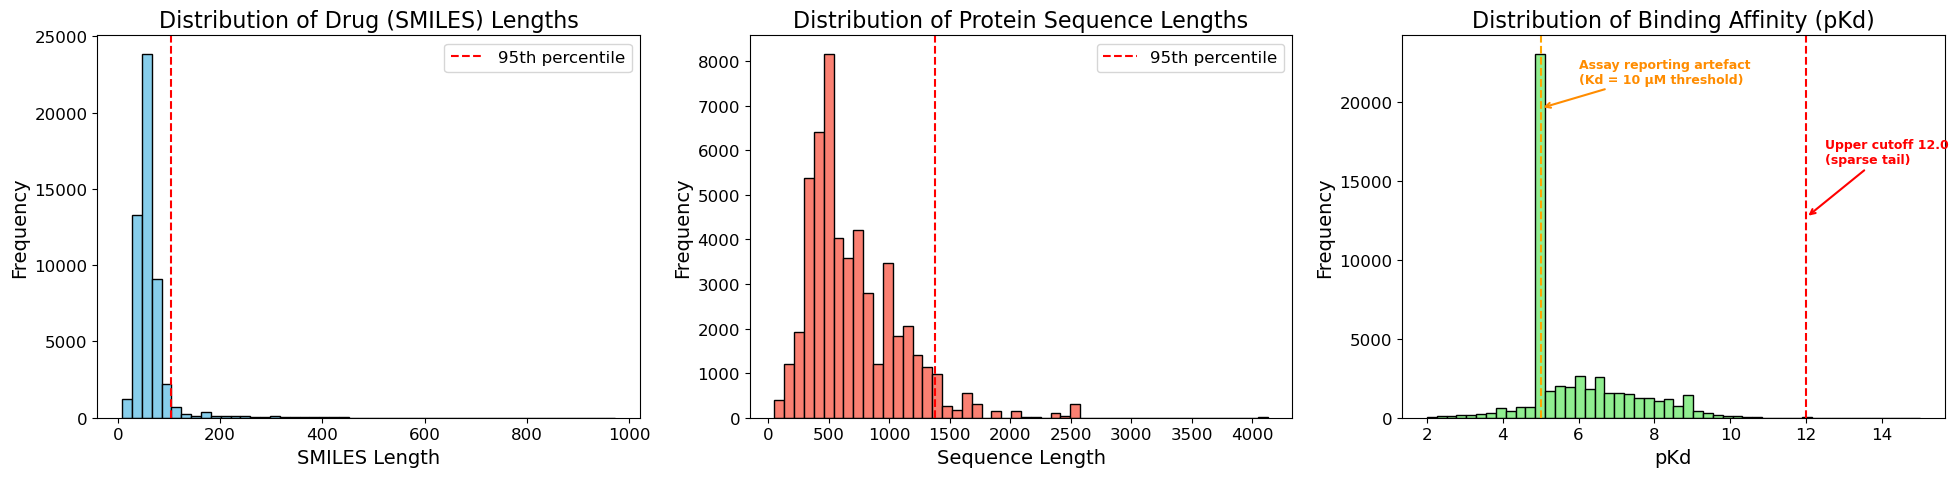

Drugs longer than 512 chars (ChemBERTa max): 0.10% of pairs

count    52272.000000
mean        63.205540
std         44.256831
min          8.000000
25%         46.000000
50%         56.000000
75%         66.000000
max        973.000000
Name: Drug, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Drug lengths - ChemBERTa truncates at 512 chars
drug_lens = df["Drug"].apply(len)
axes[0].hist(drug_lens, bins=50, color="skyblue", edgecolor="black")
axes[0].axvline(
    drug_lens.quantile(0.95),
    color="red",
    linestyle="dashed",
    linewidth=1.5,
    label="95th percentile",
)
axes[0].set_title("Distribution of Drug (SMILES) Lengths")
axes[0].set_xlabel("SMILES Length")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Protein sequence lengths — ProteinBERT has no hard length limit
prot_lens = df["Target"].apply(len)
axes[1].hist(prot_lens, bins=50, color="salmon", edgecolor="black")
axes[1].axvline(
    prot_lens.quantile(0.95),
    color="red",
    linestyle="dashed",
    linewidth=1.5,
    label="95th percentile",
)
axes[1].set_title("Distribution of Protein Sequence Lengths")
axes[1].set_xlabel("Sequence Length")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# pKd distribution
counts, edges, _ = axes[2].hist(
    df["pKd"], bins=50, color="lightgreen", edgecolor="black"
)

# Annotate the artefact spike at pKd = 5.0
axes[2].axvline(5.0, color="orange", linestyle="dashed", linewidth=1.5)
ymax = counts.max()
axes[2].annotate(
    "Assay reporting artefact\n(Kd = 10 μM threshold)",
    xy=(5.0, ymax * 0.85),
    xytext=(6.0, ymax * 0.92),
    fontsize=9,
    color="darkorange",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="darkorange", lw=1.5),
    ha="left",
)

# Annotate the upper cutoff at pKd = 12.0
axes[2].axvline(12.0, color="red", linestyle="dashed", linewidth=1.5)
axes[2].annotate(
    "Upper cutoff 12.0\n(sparse tail)",
    xy=(12.0, ymax * 0.55),
    xytext=(12.5, ymax * 0.70),
    fontsize=9,
    color="red",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
    ha="left",
)

axes[2].set_title("Distribution of Binding Affinity (pKd)")
axes[2].set_xlabel("pKd")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(
    f"Drugs longer than 512 chars (ChemBERTa max): {(drug_lens > 512).mean():.2%} of pairs"
)
print()
print(drug_lens.describe())


In [13]:
df_ranged_pKd = df[(df["pKd"] != 5.0) & (df["pKd"] <= 12.0)]
print(
    f"Pairs with pKd ≤ 12.0, pKd != 5.0: {(df_ranged_pKd.shape[0] / df.shape[0]):.2%} of total"
)


Pairs with pKd ≤ 12.0, pKd != 5.0: 57.54% of total


**Findings:**

- **Drug SMILES** — the vast majority are under 512 characters, which is the ChemBERTa tokenizer limit. Only 0.10% of pairs have drugs longer than 512. Rather than truncate (which could silently remove functionally important substructures of the molecule), we drop these pairs entirely.

- **Protein sequences** — most are under ~1024 residues. ProteinBERT handles arbitrary-length proteins (no hard limit), so no protein truncation is needed. This is one of the motivating reasons for choosing ProteinBERT over ESM-2 (which caps at 1022 tokens).

- **pKd distribution** — there is a pronounced artifact spike at exactly `pKd = 5.0`. We drop these as they are uninformative. We also cap at `pKd = 12.0` because the tail beyond this is sparse and dominated by a few very high-affinity outliers that would skew training.

This filtering step leaves us with 58% of the original data.

### 3.4 Drugs per protein distribution

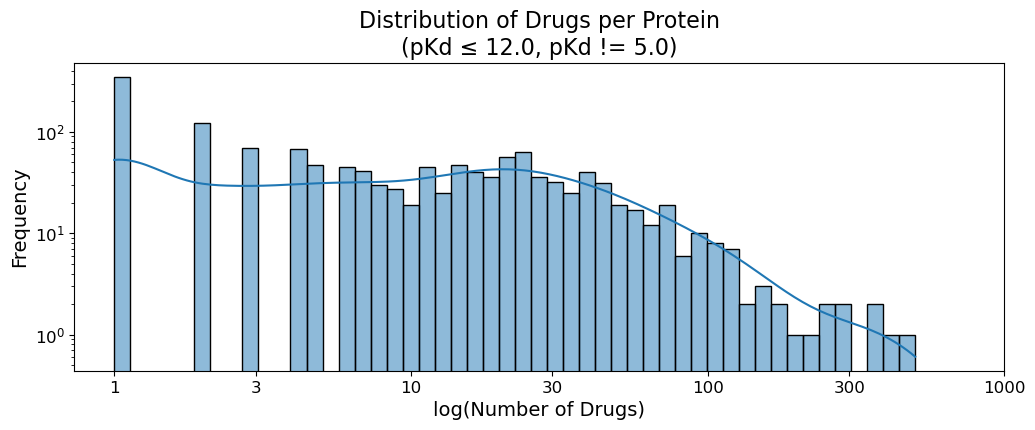

Fraction of proteins with ≥3 known binders (pKd ≤ 12.0, pKd != 5.0): 66.5%
Fraction of proteins with ≥5 known binders (pKd ≤ 12.0, pKd != 5.0): 56.8%
Fraction of proteins with ≥10 known binders (pKd ≤ 12.0, pKd != 5.0): 43.4%


In [14]:
drugs_per_protein = df_ranged_pKd.groupby("Target")["Drug"].nunique()

# Plot histogram of drugs per protein (log-log scale)
plt.figure(figsize=(12, 4))
sns.histplot(np.log10(drugs_per_protein), bins=50, kde=True)
plt.title("Distribution of Drugs per Protein\n(pKd ≤ 12.0, pKd != 5.0)")
plt.xlabel("log(Number of Drugs)")
plt.ylabel("Frequency")
plt.yscale("log")
# label x axis with unlogged ticks
ticks = [1, 3, 10, 30, 100, 300, 1000]
plt.xticks(np.log10(ticks), ticks)
plt.show()

# Print what fraction of proteins have ≥3, ≥5, ≥10 known binders
for n in [3, 5, 10]:
    frac = (drugs_per_protein >= n).mean()
    print(
        f"Fraction of proteins with ≥{n} known binders (pKd ≤ 12.0, pKd != 5.0): {frac:.1%}"
    )


**Finding:**

Most proteins have only a few known binders. This sparsity means that for most proteins, the model will have very limited per-protein supervision.

### 3.5 pKd coverage per protein

_Motivates: how much affinity diversity exists per protein — are rankings learnable?_

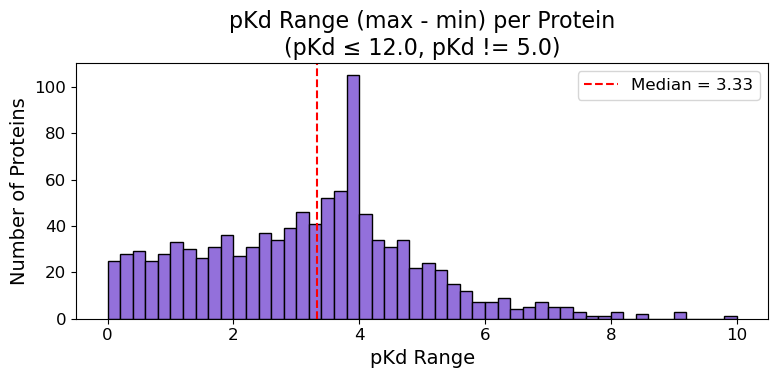

Proteins with ≥2 drugs: 1,059

Summary of pKd range per protein:
count    1059.000000
mean        3.170987
std         1.724750
min         0.000000
25%         1.845078
50%         3.334713
75%         4.142118
max        10.000000
Name: pKd, dtype: float64


In [15]:
# Only consider proteins with >=2 known drugs (need at least 2 to compute a range)
proteins_multi = drugs_per_protein[drugs_per_protein >= 2].index
df_proteins_multi = df_ranged_pKd[df_ranged_pKd["Target"].isin(proteins_multi)]

pkd_range_per_protein = df_proteins_multi.groupby("Target")["pKd"].agg(
    lambda x: x.max() - x.min()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pkd_range_per_protein, bins=50, color="mediumpurple", edgecolor="black")
ax.axvline(
    pkd_range_per_protein.median(),
    color="red",
    linestyle="dashed",
    linewidth=1.5,
    label=f"Median = {pkd_range_per_protein.median():.2f}",
)
ax.set_title("pKd Range (max - min) per Protein\n(pKd ≤ 12.0, pKd != 5.0)")
ax.set_xlabel("pKd Range")
ax.set_ylabel("Number of Proteins")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Proteins with ≥2 drugs: {len(pkd_range_per_protein):,}")
print("\nSummary of pKd range per protein:")
print(pkd_range_per_protein.describe())


**Finding:**

This means that we have enough variance in pKd values for our models to learn from.

### 3.6 Unique Protein-Drug Pairs



In [16]:
n_proteins = df["Target"].nunique()
n_drugs = df["Drug"].nunique()
avg_drugs = df.groupby("Target")["Drug"].nunique().mean()
print(f"Unique proteins: {n_proteins}")
print(f"Unique drugs: {n_drugs}")
print(f"Average drugs per protein: {avg_drugs:.1f}")


Unique proteins: 1413
Unique drugs: 10659
Average drugs per protein: 32.6


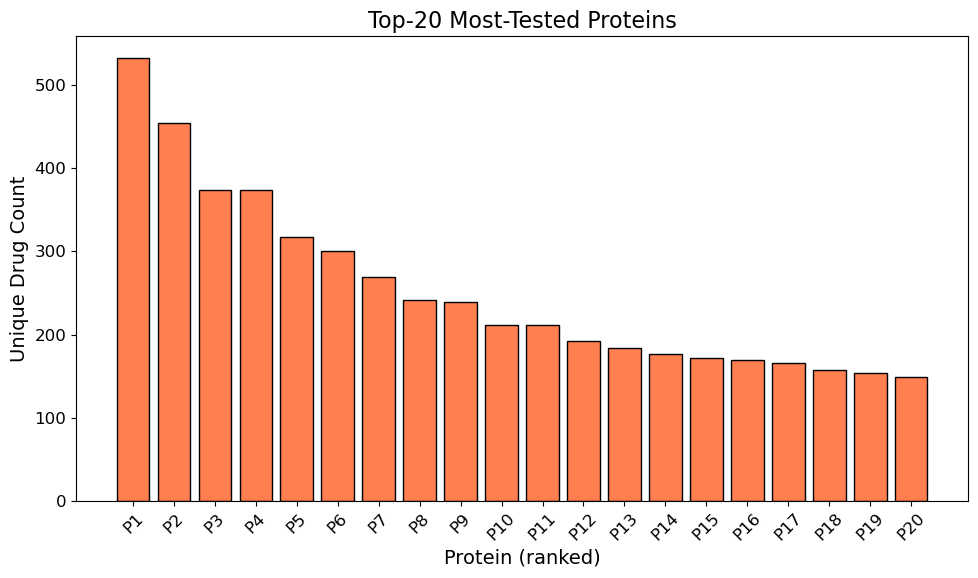

In [17]:
top20 = df.groupby("Target")["Drug"].nunique().nlargest(20)
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(20), top20.values, color="coral", edgecolor="black")
ax.set_xticks(range(20))
ax.set_xticklabels([f"P{i + 1}" for i in range(20)], rotation=45)
ax.set_title("Top-20 Most-Tested Proteins")
ax.set_xlabel("Protein (ranked)")
ax.set_ylabel("Unique Drug Count")
plt.tight_layout()
plt.show()


In [18]:
dupes = df.groupby(["Drug", "Target"])["Y"].nunique()
conflict_pairs = (dupes > 1).sum()
print(f"Drug-protein pairs with conflicting Y values: {conflict_pairs}")


Drug-protein pairs with conflicting Y values: 3488


**Findings:**
- The average of 32.6 drugs-protein is misleading because the top-20 hub proteins each have 150–530 binders while the majority have fewer than 5.
- This extreme imbalance means the model will be trained mostly on hub-protein chemistry, and generalization to rare proteins will be a challenge.

To characterise the spread of repeated `(Drug, Target)` measurements we plot the distribution of pKd standard deviation (SD) across replicate pairs. This informs our understanding of inter-lab noise, **but does not drive a filtering decision** — see the finding below for our rationale.

In [19]:
def inspect_repeat_sds(data, stage_name):
    repeat_mask = data.duplicated(subset=["Drug", "Target"], keep=False)
    repeats = data[repeat_mask]

    if len(repeats) == 0:
        print(f"[{stage_name}] No repeat pairs.")
        return None

    sd = repeats.groupby(["Drug", "Target"])["pKd"].std(ddof=1).dropna()
    n_pairs = len(sd)
    print(f"[{stage_name}]")
    print(f"  Total rows:           {len(data):>8,}")
    print(f"  Rows in repeat pairs: {len(repeats):>8,}")
    print(f"  Unique repeat pairs:  {n_pairs:>8,}")
    print(f"  Median SD:            {sd.median():>8.3f}")
    print(f"  Mean SD:              {sd.mean():>8.3f}")
    for thr in [0.5, 1.0, 1.5, 2.0, 2.5]:
        n_drop = (sd > thr).sum()
        print(
            f"  SD > {thr}:  drop {n_drop:>5,} / {n_pairs:,} pairs ({n_drop / n_pairs:>5.1%})"
        )
    print()
    return sd


# Apply the same filters we'll use in Section 4, then look at repeat SDs
df_filt = df[(df["pKd"] != 5.0) & (df["pKd"] <= 12.0) & (df["Drug"].str.len() <= 512)]
sd_filt = inspect_repeat_sds(df_filt, "AFTER pKd != 5.0, pKd <= 12.0, SMILES <= 512")


[AFTER pKd != 5.0, pKd <= 12.0, SMILES <= 512]
  Total rows:             30,025
  Rows in repeat pairs:    7,195
  Unique repeat pairs:     2,370
  Median SD:               0.438
  Mean SD:                 0.601
  SD > 0.5:  drop 1,083 / 2,370 pairs (45.7%)
  SD > 1.0:  drop   453 / 2,370 pairs (19.1%)
  SD > 1.5:  drop   169 / 2,370 pairs ( 7.1%)
  SD > 2.0:  drop    89 / 2,370 pairs ( 3.8%)
  SD > 2.5:  drop    44 / 2,370 pairs ( 1.9%)



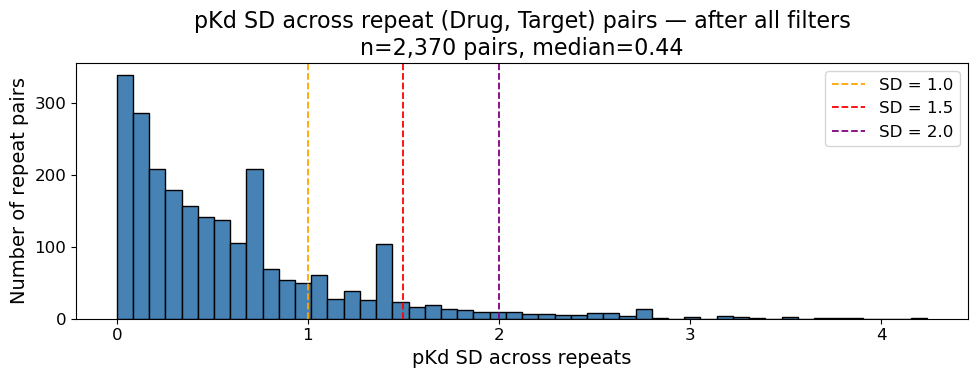

In [20]:
# Visualize the SD distribution with threshold markers
if sd_filt is not None and len(sd_filt) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(sd_filt, bins=50, color="steelblue", edgecolor="black")
    for thr, color in [(1.0, "orange"), (1.5, "red"), (2.0, "purple")]:
        ax.axvline(thr, color=color, linestyle="--", linewidth=1.3, label=f"SD = {thr}")
    ax.set_title(
        f"pKd SD across repeat (Drug, Target) pairs — after all filters\n"
        f"n={len(sd_filt):,} pairs, median={sd_filt.median():.2f}"
    )
    ax.set_xlabel("pKd SD across repeats")
    ax.set_ylabel("Number of repeat pairs")
    ax.legend()
    plt.tight_layout()
    plt.show()


**Finding:** After filtering out the `pKd = 5.0` assay artifact and capping at 12.0, the remaining repeat-pair SD distribution reflects genuine inter-lab noise. The median SD is ~0.4–0.6 pKd units — labs typically agree to within a factor of ~2–4 in Kd. This sets a practical floor on model performance: no predictor can do better than the labels themselves.

**Decision — keep all observations separate:**

We initially considered two preprocessing steps for handling repeat measurements are (1) averaging replicates into a single consensus value and (2) dropping pairs whose SD exceeds a threshold. After discussion, we decided to avoid both for the following reasons:

- **Averaging collapses a random variable into a point estimate.** pKd is not a fixed property of a pair — it is a noisy measurement drawn from a distribution that reflects experimental conditions, assay variability, and genuine biological uncertainty. Averaging discards exactly the variance information we want the model to learn.
- **Dropping high-SD pairs discards useful signal.** High spread does not mean the measurements are wrong; it can reflect real assay sensitivity differences or biologically interesting edge cases. Removing these pairs introduces a selection bias toward artificially "clean" data.

We therefore retain **all individual observations** as separate training examples. The model is trained to predict the distribution of pKd values (via a probabilistic output head), so repeated measurements for the same pair provide direct supervision on the uncertainty. As a future experiment, we can run ablations with SD-based filtering and averaging to quantify the effect on held-out performance.

In [21]:
df_filt = df[(df["pKd"] != 5.0) & (df["pKd"] <= 12.0) & (df["Drug"].str.len() <= 512)]
print("\nAFTER data cleaning: drop pKd == 5.0, cap pKd <= 12.0, SMILES <= 512")
print(
    f"  Percentage of pairs dropped: {100 * (1 - df_filt.shape[0] / df.shape[0]):.1f}%"
)
print(f"  Unique proteins: {df_filt['Target'].nunique():>7,}")
print(f"  Unique drugs:    {df_filt['Drug'].nunique():>7,}")
print(f"  Total pairs:     {df_filt.shape[0]:>7,}")
print(f"  Avg drugs/protein: {df_filt.shape[0] / df_filt['Target'].nunique():.1f}")



AFTER data cleaning: drop pKd == 5.0, cap pKd <= 12.0, SMILES <= 512
  Percentage of pairs dropped: 42.6%
  Unique proteins:   1,403
  Unique drugs:     10,527
  Total pairs:      30,025
  Avg drugs/protein: 21.4


### 3.7 Protein families, drug classes, and class imbalance

Protein family labels were assigned by querying the UniProt REST API for each `Target_ID` and applying keyword matching against the `PROTEIN_FAMILIES` dictionary below. Results are cached in `bindingdb_kd_with_proteinfamily.csv`.

**Class definition:** we keep all labeled families as their own categories. Proteins
with a missing (NaN) family label are bucketed into `"other"`.

In [22]:
PROTEIN_FAMILIES = {
    "kinase": ["kinase"],
    "protease": ["protease", "peptidase"],
    "GPCR": [
        "gpcr",
        "adrenergic",
        "dopamine",
        "serotonin",
        "muscarinic",
        "histamine",
        "opioid",
    ],
    "nuclear receptor": ["nuclear receptor", "androgen", "estrogen", "glucocorticoid"],
    "ion channel": ["channel", "transporter"],
    "carbohydrase": ["glucosidase", "amylase", "glycosidase", "carbohydrase"],
    "oxidoreductase": ["oxidase", "reductase", "dehydrogenase", "peroxidase"],
    "phosphatase": ["phosphatase"],
    "other": [],
}
CACHE_PATH = "./data/uniprot_name_cache.csv"


def fetch_uniprot_info(uniprot_id):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.json"
    response = requests.get(url)

    if response.status_code != 200:
        return None

    data = response.json()

    # Extract useful text fields
    protein_name = (
        data.get("proteinDescription", {})
        .get("recommendedName", {})
        .get("fullName", {})
        .get("value", "")
    )

    comments = []
    for c in data.get("comments", []):
        if "texts" in c:
            comments.extend([t["value"] for t in c["texts"]])

    text_blob = " ".join([protein_name] + comments).lower()
    return text_blob


def assign_protein_family(text):
    for family, keywords in PROTEIN_FAMILIES.items():
        for kw in keywords:
            if kw in text:
                return family
    return "other"


def load_cache():
    if os.path.exists(CACHE_PATH):
        return pd.read_csv(CACHE_PATH)
    return pd.DataFrame(columns=["uniprot_id", "text", "family"])


def save_cache(df):
    df.to_csv(CACHE_PATH, index=False)


def retrieve_and_append_pf(df):
    cache_df = load_cache()
    existing_ids = set(cache_df["uniprot_id"])

    unique_targets = df["Target_ID"].dropna().unique()
    missing_ids = [tid for tid in unique_targets if tid not in existing_ids]

    print(f"Querying {len(missing_ids)} new proteins...")

    new_rows = []

    for i, tid in enumerate(missing_ids):
        text = fetch_uniprot_info(tid)

        if text is None:
            family = "other"
        else:
            family = assign_protein_family(text)

        new_rows.append({"uniprot_id": tid, "text": text, "family": family})

        time.sleep(0.1)

        if i % 50 == 0:
            print(f"{i}/{len(missing_ids)} processed")

    if new_rows:
        new_df = pd.DataFrame(new_rows)
        cache_df = pd.concat([cache_df, new_df], ignore_index=True)
        save_cache(cache_df)

    df = df.merge(
        cache_df[["uniprot_id", "family"]],
        left_on="Target_ID",
        right_on="uniprot_id",
        how="left",
    )

    df = df.rename(columns={"family": "Protein_Family"})
    df = df.drop(columns=["uniprot_id"])

    return df


In [23]:
Path("./data").mkdir(exist_ok=True)

pf_path = Path("./data/bindingdb_kd_with_proteinfamily.csv")
raw_path = Path("./data/bindingdb_kd.csv")

if pf_path.exists():
    df = pd.read_csv(pf_path)
    print("Loaded dataset WITH protein families from disk")
else:
    if raw_path.exists():
        df = pd.read_csv(raw_path)
        print("Loaded raw dataset from disk")
    else:
        data = DTI(name="BindingDB_Kd")
        df = data.get_data()
        df.to_csv(raw_path, index=False)
        print("Downloaded and saved raw dataset")

    print("Generating protein families...")
    df = retrieve_and_append_pf(df)
    df.to_csv(pf_path, index=False)
    print("Saved dataset WITH protein families")

print(f"\nShape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nBasic stats:")
print(df.describe())


Loaded dataset WITH protein families from disk

Shape: (52274, 6)
Columns: ['Drug_ID', 'Drug', 'Target_ID', 'Target', 'Y', 'Protein_Family']

Basic stats:
            Drug_ID             Y
count  5.227400e+04  5.227400e+04
mean   2.587647e+07  4.353189e+04
std    3.469676e+07  4.102312e+05
min    5.100000e+01  0.000000e+00
25%    5.328940e+06  2.200000e+02
50%    1.107117e+07  9.800000e+03
75%    2.518873e+07  1.000000e+04
max    1.388059e+08  1.000000e+07


Filled 3,215 missing Protein_Family labels with 'other'

Protein family breakdown:
Protein_Family
kinase              16952
GPCR                 6523
other                5499
ion channel           400
protease              329
oxidoreductase        264
nuclear receptor       31
phosphatase            27
Name: count, dtype: int64

Target
MADQLTEEQIAEFKEAFSLFDKDGDGTITTKELGTVMRSLGQNPTEAELQDMINEVDADGNGTIDFPEFLTMMARKMKDTDSEEEIREAFRVFDKDGNGYISAAELRHVMTNLGEKLTDEEVDEMIREADIDGDGQVNYEEFVQMMTAK    2
Name: Protein_Family, dtype: int64


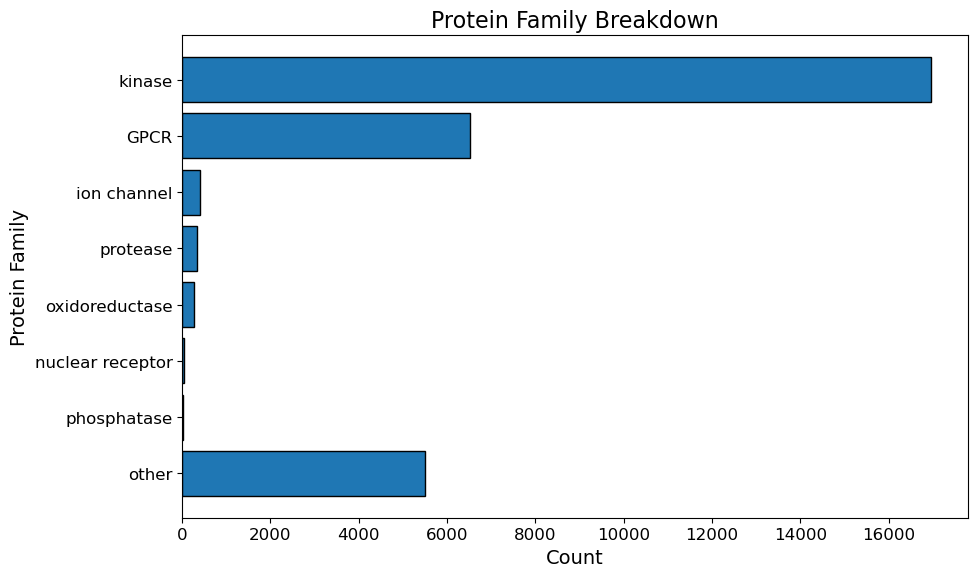

In [24]:
# Fill missing Protein_Family with "other" so the plots and stratification are consistent.
df_families = df_filt.copy()

n_missing = df_families["Protein_Family"].isna().sum()
df_families["Protein_Family"] = df_families["Protein_Family"].fillna("other")
print(f"Filled {n_missing:,} missing Protein_Family labels with 'other'")
print()
print("Protein family breakdown:")
print(df_families["Protein_Family"].value_counts())
print()

# Sanity: ensure each protein is in exactly one family (post-fillna, no NaN)
protein_family_counts = df_families.groupby("Target")["Protein_Family"].nunique()
conflicting_proteins = protein_family_counts[protein_family_counts > 1]
if len(conflicting_proteins) > 0:
    print(
        f"Warning: {len(conflicting_proteins)} proteins have conflicting family annotations"
    )
    print(conflicting_proteins.head())
else:
    print("All proteins map to a single family (no conflicts).")

family_counts = df_families["Protein_Family"].value_counts()

if "other" in family_counts.index:
    other_count = family_counts.pop("other")
    family_counts.loc["other"] = other_count

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(family_counts.index, family_counts.values, edgecolor="black")
ax.set_title("Protein Family Breakdown")
ax.set_xlabel("Count")
ax.set_ylabel("Protein Family")
ax.invert_yaxis()

plt.tight_layout()
plt.show()


**Finding — class imbalance:** The dataset is heavily skewed toward kinases, followed by GPCRs. This reflects the commercial focus of pharmaceutical research, where kinases are the most heavily screened class.

**Implication for modeling:**
- We mitigate this by using `StratifiedShuffleSplit` on protein family (on top of per protein split) in Section 4. Rare families are grouped into a coarse "other" bucket for stratification purposes (so each split gets proportional representation), while the fine-grained label is preserved for per-family metric reporting at evaluation time.

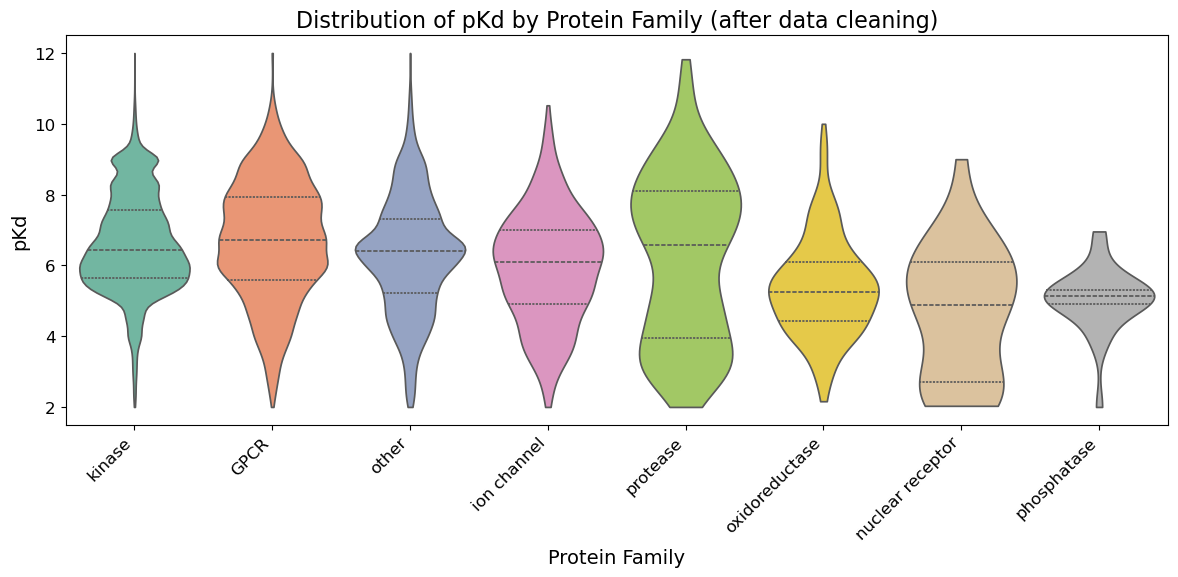

In [25]:
# Violin plot: distribution of pKd by protein family
plt.figure(figsize=(12, 6))
order = df_families["Protein_Family"].value_counts().index.tolist()
sns.violinplot(
    x="Protein_Family",
    y="pKd",
    data=df_families,
    order=order,
    inner="quartile",
    palette="Set2",
    cut=0,
)
plt.title("Distribution of pKd by Protein Family (after data cleaning)")
plt.xlabel("Protein Family")
plt.ylabel("pKd")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


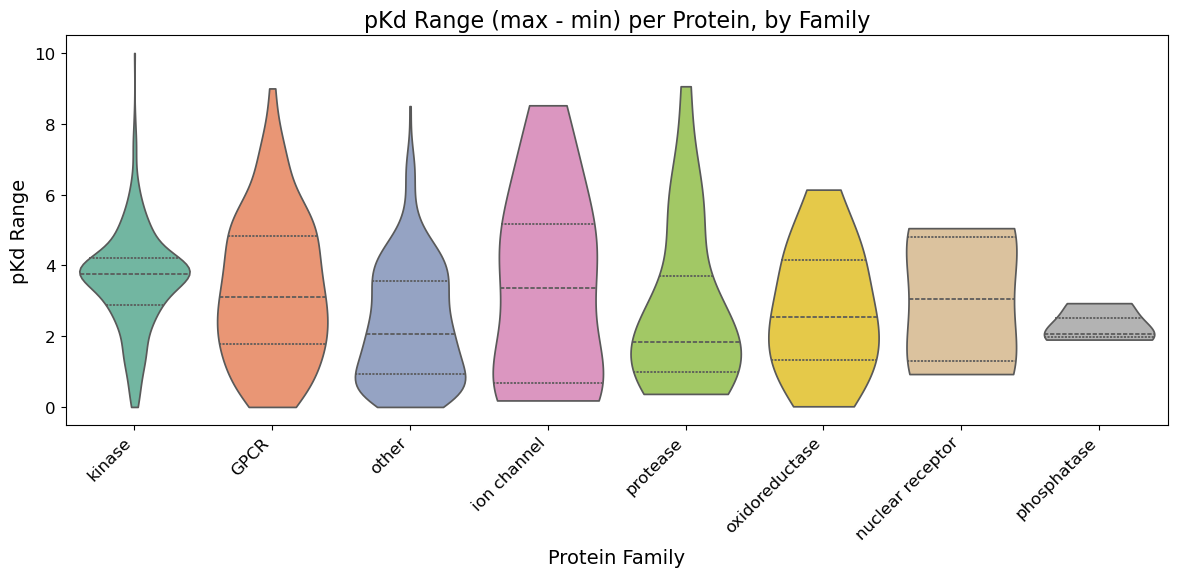

In [26]:
# Violin plot: pKd range (max - min) per protein, grouped by family
# Drop proteins with only 1 measurement (range would trivially be 0)
df_multi_drug = df_families.groupby(["Target", "Protein_Family"]).filter(
    lambda x: len(x) > 1
)

pkd_range_per_protein_family = (
    df_multi_drug.groupby(["Target", "Protein_Family"])["pKd"]
    .agg(lambda x: x.max() - x.min())
    .reset_index(name="pKd_range")
)

plt.figure(figsize=(12, 6))
sns.violinplot(
    x="Protein_Family",
    y="pKd_range",
    data=pkd_range_per_protein_family,
    order=order,
    inner="quartile",
    palette="Set2",
    cut=0,
)
plt.title("pKd Range (max - min) per Protein, by Family")
plt.xlabel("Protein Family")
plt.ylabel("pKd Range")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Finding:**

From these 2 graphs, there are differences in protein family distributions of pKd, and therefore providing the model with the class information might be helpful for prediction. None of the classes seem defunct, so we can keep all of them for modelling.

## 4. Preprocessing

Each filtering step below is motivated by a specific EDA finding. The preprocessing
pipeline is:

1. Drop exact duplicate rows `(Drug, Target, Y)`
2. Drop the `pKd == 5.0` assay artifact and cap at `pKd <= 12.0` (keeps weaker binders below 5.0)
3. Drop drugs with SMILES > 512 characters (ChemBERTa limit — we drop rather than truncate)
4. **Keep ALL repeat `(Drug, Target)` measurements** — no SD-based filtering or averaging; the goal is to learn the pKd distribution over repeated measurements
5. No protein truncation (ProteinBERT handles arbitrary length)
6. Stratified 70/15/15 split by protein identity, stratified by coarse protein family

In [27]:
PKD_ARTEFACT = 5.0  # drop pairs with pKd == exactly this (Kd = 10 uM assay ceiling)
PKD_MAX = 12.0  # inclusive upper cap — drops sparse high-affinity tail
MAX_SMILES_LEN = 512  # ChemBERTa tokenizer hard limit


In [28]:
# Reload from disk so re-running this section starts from a clean raw df
df_raw = (
    pd.read_csv("./data/bindingdb_kd_with_proteinfamily.csv")
    if Path("./data/bindingdb_kd_with_proteinfamily.csv").exists()
    else pd.read_csv("./data/bindingdb_kd.csv")
)

n0 = len(df_raw)
steps = [("Raw dataset", n0)]

# 0. Drop Y == 0 (would produce infinite pKd) and compute pKd
df_raw = df_raw[df_raw["Y"] != 0].copy()
df_raw["pKd"] = -np.log10(df_raw["Y"] / 1e9)
steps.append(("Drop Y == 0", len(df_raw)))

# 0b. Fill missing Protein_Family with 'other' (the NaN-only definition)
if "Protein_Family" in df_raw.columns:
    df_raw["Protein_Family"] = df_raw["Protein_Family"].fillna("other")

# 1. Drop exact duplicate rows
df_step = df_raw.drop_duplicates(subset=["Drug", "Target", "Y"]).copy()
steps.append(("Drop exact duplicate rows", len(df_step)))

# 2. pKd filter — drop the exact 5.0 assay artifact and cap at PKD_MAX
df_step = df_step[(df_step["pKd"] != PKD_ARTEFACT) & (df_step["pKd"] <= PKD_MAX)].copy()
steps.append((f"Drop pKd == {PKD_ARTEFACT} and cap at pKd <= {PKD_MAX}", len(df_step)))

# 3. SMILES length filter
df_step = df_step[df_step["Drug"].str.len() <= MAX_SMILES_LEN].copy()
steps.append((f"SMILES <= {MAX_SMILES_LEN} chars", len(df_step)))

# 4. Keep ALL repeat (Drug, Target) measurements — no SD filtering or averaging.
#    Retaining all replicates lets the model learn the pKd distribution; the
#    spread of repeated measurements reflects genuine inter-lab noise.
steps.append(("Keep all repeat measurements (learn pKd distribution)", len(df_step)))

# 5. No protein truncation (ProteinBERT handles arbitrary length)
steps.append(("No protein truncation (ProteinBERT)", len(df_step)))

# 6. Add length convenience columns
df_step["Drug_len"] = df_step["Drug"].str.len()
df_step["Target_len"] = df_step["Target"].str.len()

df_clean = df_step.reset_index(drop=True)

print("=== Preprocessing Summary ===")
summary = pd.DataFrame(steps, columns=["Step", "Pairs"])
summary["% of raw"] = (summary["Pairs"] / n0 * 100).round(1)
print(summary.to_string(index=False))
print(f"\nFinal clean dataset: {len(df_clean):,} pairs")
print(f"  Unique proteins: {df_clean['Target'].nunique():,}")
print(f"  Unique drugs:    {df_clean['Drug'].nunique():,}")
print(
    f"  Repeat (Drug, Target) pairs: {df_clean.duplicated(subset=['Drug', 'Target']).sum():,}"
)


=== Preprocessing Summary ===
                                                 Step  Pairs  % of raw
                                          Raw dataset  52274     100.0
                                          Drop Y == 0  52272     100.0
                            Drop exact duplicate rows  52272     100.0
               Drop pKd == 5.0 and cap at pKd <= 12.0  30076      57.5
                                  SMILES <= 512 chars  30025      57.4
Keep all repeat measurements (learn pKd distribution)  30025      57.4
                  No protein truncation (ProteinBERT)  30025      57.4

Final clean dataset: 30,025 pairs
  Unique proteins: 1,403
  Unique drugs:    10,527
  Repeat (Drug, Target) pairs: 4,825


### 4.1 Train / validation / test split — stratified by protein family

In [29]:
# Stratified 70/15/15 split by protein identity, with stratification on protein family.
# "other" is defined as NaN only — all labeled families (including rare ones) keep
# their own stratum. This matches the NaN-only definition used in cell 34.
def coarse_family(fam):
    return "other" if pd.isna(fam) else fam


# Build one row per unique protein with its family label
if "Protein_Family" in df_clean.columns:
    protein_fam = (
        df_clean.groupby("Target")["Protein_Family"]
        .agg(lambda s: s.mode().iat[0] if len(s.mode()) else "other")
        .reset_index()
    )
    protein_fam["stratum"] = protein_fam["Protein_Family"].apply(coarse_family)
else:
    protein_fam = pd.DataFrame({"Target": df_clean["Target"].unique()})
    protein_fam["stratum"] = "other"

print("Family distribution across unique proteins:")
print(protein_fam["stratum"].value_counts())
print()

# Stratified 70/15/15 split at the PROTEIN level
proteins = protein_fam["Target"].values
strata = protein_fam["stratum"].values

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
trainval_idx, test_idx = next(sss1.split(proteins, strata))

sss2 = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.15 / 0.85,  # 15/85 of what remains -> 15% of original
    random_state=SEED,
)
train_idx, val_idx = next(sss2.split(proteins[trainval_idx], strata[trainval_idx]))

test_proteins = set(proteins[test_idx])
val_proteins = set(proteins[trainval_idx][val_idx])
train_proteins = set(proteins[trainval_idx][train_idx])


def assign_split(target):
    if target in test_proteins:
        return "test"
    if target in val_proteins:
        return "val"
    return "train"


df_clean["split"] = df_clean["Target"].apply(assign_split)

# Sanity check: no protein should appear in more than one split (no leakage)
assert not (train_proteins & val_proteins), "LEAKAGE: train ∩ val"
assert not (train_proteins & test_proteins), "LEAKAGE: train ∩ test"
assert not (val_proteins & test_proteins), "LEAKAGE: val   ∩ test"
print("Leakage check passed: no protein appears in more than one split.")
print()

split_counts = df_clean["split"].value_counts()
print("Split sizes (pairs):")
for s in ["train", "val", "test"]:
    n_pairs = split_counts.get(s, 0)
    n_prot = df_clean[df_clean["split"] == s]["Target"].nunique()
    print(
        f"  {s:5s}: {n_pairs:>7,} pairs ({n_pairs / len(df_clean):5.1%})  |  {n_prot:,} proteins"
    )


Family distribution across unique proteins:
stratum
other               523
kinase              523
GPCR                265
protease             34
ion channel          27
oxidoreductase       21
nuclear receptor      6
phosphatase           4
Name: count, dtype: int64

Leakage check passed: no protein appears in more than one split.

Split sizes (pairs):
  train:  22,750 pairs (75.8%)  |  981 proteins
  val  :   3,407 pairs (11.3%)  |  211 proteins
  test :   3,868 pairs (12.9%)  |  211 proteins


In [30]:
# Save the full clean dataset and one CSV per split.
# Downstream code can load these directly without re-running preprocessing.
Path("./data/splits").mkdir(exist_ok=True)

df_clean.to_csv("./data/splits/df_clean.csv", index=False)
for split in ["train", "val", "test"]:
    df_clean[df_clean["split"] == split].to_csv(
        f"./data/splits/{split}.csv", index=False
    )

print("Saved to ./data/splits/")
for name in ["train", "val", "test", "df_clean"]:
    rows = len(df_clean) if name == "df_clean" else (df_clean["split"] == name).sum()
    print(f"  {name}.csv  {rows:>7,} rows")


Saved to ./data/splits/
  train.csv   22,750 rows
  val.csv    3,407 rows
  test.csv    3,868 rows
  df_clean.csv   30,025 rows


### 4.2 Split-bias sanity checks

There are obvious differences in the distribution of various metrics between splits, providing further evidence in support of our split approach.

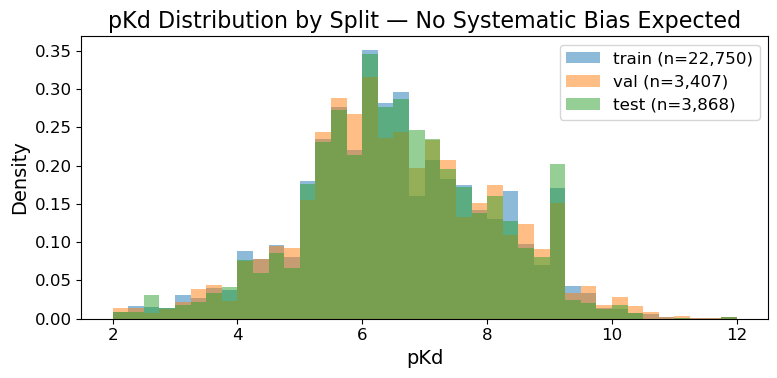

In [31]:
# pKd distribution per split
fig, ax = plt.subplots(figsize=(8, 4))
for s in ["train", "val", "test"]:
    vals = df_clean[df_clean["split"] == s]["pKd"]
    ax.hist(vals, bins=40, alpha=0.5, density=True, label=f"{s} (n={len(vals):,})")
ax.set_title("pKd Distribution by Split — No Systematic Bias Expected")
ax.set_xlabel("pKd")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()


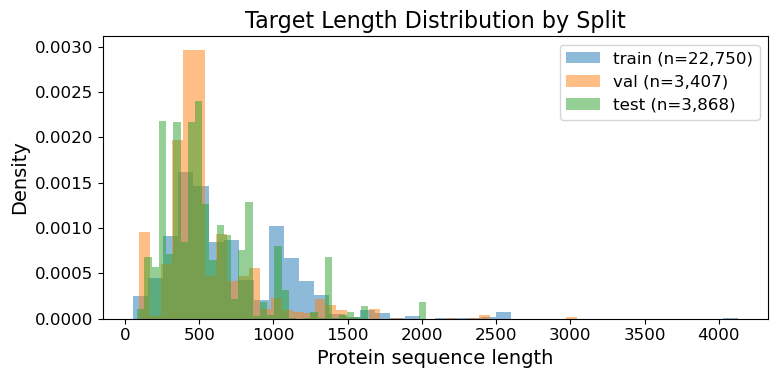

In [32]:
# Target length distribution per split
fig, ax = plt.subplots(figsize=(8, 4))
for s in ["train", "val", "test"]:
    vals = df_clean[df_clean["split"] == s]["Target_len"]
    ax.hist(vals, bins=40, alpha=0.5, density=True, label=f"{s} (n={len(vals):,})")
ax.set_title("Target Length Distribution by Split")
ax.set_xlabel("Protein sequence length")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()


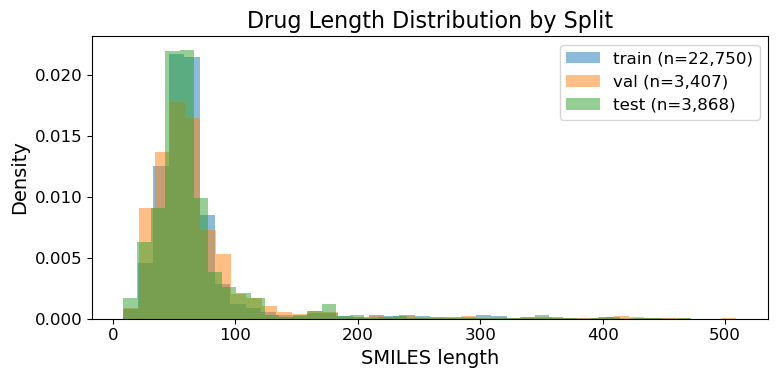

In [33]:
# Drug length distribution per split
fig, ax = plt.subplots(figsize=(8, 4))
for s in ["train", "val", "test"]:
    vals = df_clean[df_clean["split"] == s]["Drug_len"]
    ax.hist(vals, bins=40, alpha=0.5, density=True, label=f"{s} (n={len(vals):,})")
ax.set_title("Drug Length Distribution by Split")
ax.set_xlabel("SMILES length")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()


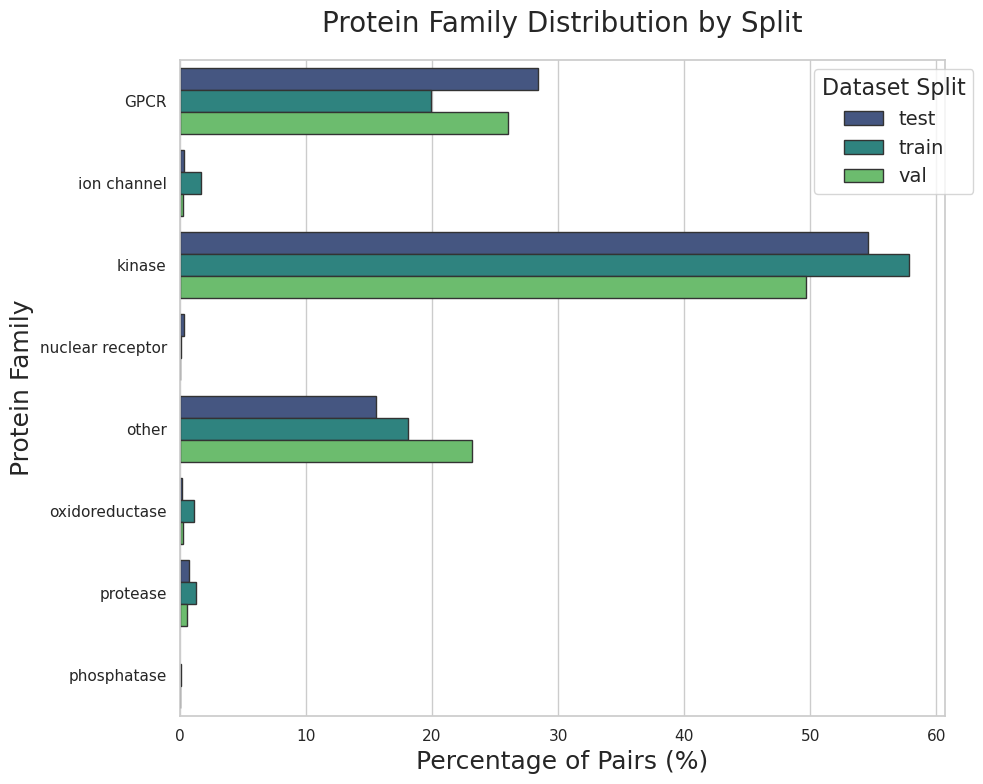

In [34]:
# Protein family distribution per split
df_plot = df_clean.assign(coarse=df_clean["Protein_Family"].apply(coarse_family))
fam_counts = df_plot.groupby(["split", "coarse"]).size().reset_index(name="counts")

total_counts = fam_counts.groupby("split")["counts"].transform("sum")
fam_counts["percentage"] = (fam_counts["counts"] / total_counts) * 100

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=fam_counts,
    y="coarse",
    x="percentage",
    hue="split",
    palette="viridis",
    edgecolor="0.2",
)

plt.title("Protein Family Distribution by Split", fontsize=20, pad=20)
plt.xlabel("Percentage of Pairs (%)", fontsize=18)
plt.ylabel("Protein Family", fontsize=18)
plt.legend(
    title="Dataset Split", fontsize=14, title_fontsize=16, bbox_to_anchor=(1.05, 1)
)
plt.tight_layout()
plt.show()


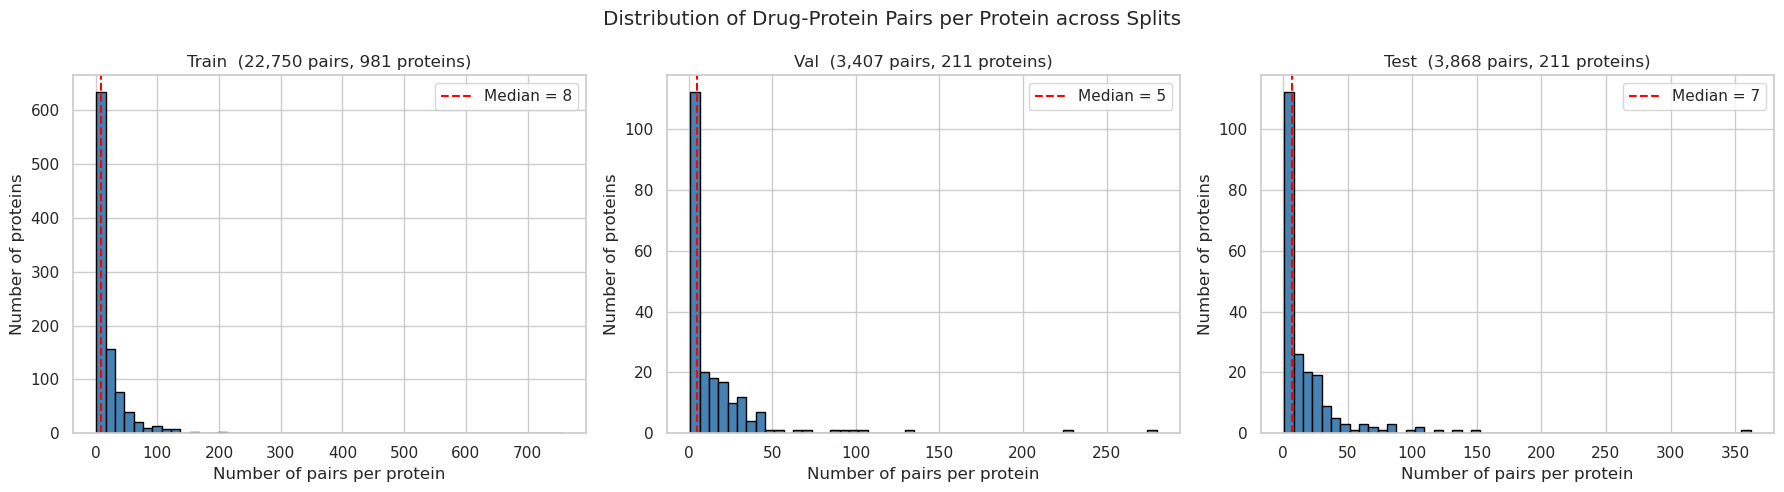

Split      Proteins    Min   Median     Mean    Max  ≥10 pairs
----------------------------------------------------------
Train           981      1      8.0     23.2    757        449
Val             211      1      5.0     16.1    280         88
Test            211      1      7.0     18.3    362         99


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribution of Drug-Protein Pairs per Protein across Splits")

for ax, split in zip(axes, ["train", "val", "test"]):
    counts = df_clean[df_clean["split"] == split].groupby("Target").size()
    ax.hist(counts, bins=50, color="steelblue", edgecolor="black")
    ax.axvline(
        counts.median(),
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Median = {counts.median():.0f}",
    )
    ax.set_title(
        f"{split.capitalize()}  ({counts.sum():,} pairs, {len(counts):,} proteins)"
    )
    ax.set_xlabel("Number of pairs per protein")
    ax.set_ylabel("Number of proteins")
    ax.legend()

plt.tight_layout()
plt.show()

print(
    f"{'Split':<8} {'Proteins':>10} {'Min':>6} {'Median':>8} {'Mean':>8} {'Max':>6} {'≥10 pairs':>10}"
)
print("-" * 58)
for split in ["train", "val", "test"]:
    c = df_clean[df_clean["split"] == split].groupby("Target").size()
    print(
        f"{split.capitalize():<8} {len(c):>10,} {c.min():>6} {c.median():>8.1f} "
        f"{c.mean():>8.1f} {c.max():>6} {(c >= 10).sum():>10,}"
    )


## 5. Summary of EDA and Preprocessing Findings

The dataset was cleaned to improve physical plausibility, measurement consistency, and model compatibility.

Entries with `Kd = 0.0` were removed before transforming affinities to `pKd`. The `pKd = 5.0` assay artifact was excluded, and entries with `pKd > 12.0` were removed as physically implausible. Compounds with SMILES strings longer than 512 characters were dropped to stay within the ChemBERTa input limit. **All repeated `(Drug, Target)` measurements are retained** — no SD-based filtering and no averaging — so the model can learn the full distribution of pKd values including inter-lab noise. The final train/validation/test split was performed at the protein level with stratification by family to reduce leakage and preserve class balance.

A key data finding is that the dataset is strongly imbalanced across protein families. Kinases dominate the data, followed by GPCRs. Missing family labels were reassigned to `other`. The strong family imbalance should be kept in mind when interpreting model performance.

## 6. Encoders — ProteinBERT & ChemBERTa

| Encoder | Input | Output dim | Max length | Frozen |
|---|---|---|---|---|
| ProteinBERT (`Rostlab/prot_bert_bfd`) | Amino acid sequence | 1024 | Unlimited | Yes |
| ChemBERTa (`DeepChem/ChemBERTa-100M-MLM`) | SMILES | 768 | 512 tokens | Yes |

Both encoders are used **frozen**. Embeddings are pre-computed once for all unique drugs and proteins in `df_clean` — covering train, val, and test splits — and cached to disk. No split leakage: embeddings contain only sequence information, no affinity labels.

Two versions are saved for each encoder:
- **Full** `(seq_len, hidden_dim)` — per-token embeddings, padding stripped. We can extract the [CLS] token for a global representation, or use the full sequence for cross-attention.
- **Pooled** `(hidden_dim,)` — mean of non-padding token embeddings. Optional for downstream experiments.

In [36]:
CHEMBERTA_MODEL = "DeepChem/ChemBERTa-100M-MLM"
PROTEINBERT_MODEL = "Rostlab/prot_bert_bfd"

_encoders_cache = {}


def load_encoders():
    if _encoders_cache:
        return _encoders_cache

    transformers.logging.set_verbosity_error()

    chem_tokenizer = AutoTokenizer.from_pretrained(CHEMBERTA_MODEL)
    chem_model = AutoModel.from_pretrained(CHEMBERTA_MODEL).to(DEVICE).eval()
    prot_tokenizer = AutoTokenizer.from_pretrained(PROTEINBERT_MODEL)
    prot_model = AutoModel.from_pretrained(PROTEINBERT_MODEL).to(DEVICE).eval()
    transformers.logging.set_verbosity_warning()

    _encoders_cache.update(
        {
            "chem_tokenizer": chem_tokenizer,
            "chem_model": chem_model,
            "prot_tokenizer": prot_tokenizer,
            "prot_model": prot_model,
            "DRUG_DIM": chem_model.config.hidden_size,
            "PROT_DIM": prot_model.config.hidden_size,
        }
    )

    print(f"ChemBERTa hidden dim: {_encoders_cache['DRUG_DIM']}")
    print(f"ProteinBERT hidden dim: {_encoders_cache['PROT_DIM']}")

    return _encoders_cache


def mean_pool(hidden_states, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
    return (hidden_states * mask).sum(1) / mask.sum(1).clamp(min=1e-9)


In [37]:
def mean_pool(hidden_states, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(hidden_states.size()).float()
    return (hidden_states * mask).sum(1) / mask.sum(1).clamp(min=1e-9)


In [45]:
from pathlib import Path

for f in ["./data/drug_emb_pooled.pt", "./data/drug_emb_full.pt"]:
    p = Path(f)
    if p.exists():
        p.unlink()
        print("Deleted:", f)

Deleted: ./data/drug_emb_pooled.pt
Deleted: ./data/drug_emb_full.pt


In [46]:
DRUG_POOLED_PATH = Path("./data/drug_emb_pooled.pt")
DRUG_FULL_PATH = Path("./data/drug_emb_full.pt")

if DRUG_POOLED_PATH.exists() and DRUG_FULL_PATH.exists():
    drug_emb_pooled = torch.load(DRUG_POOLED_PATH, weights_only=True)
    drug_emb_full = torch.load(DRUG_FULL_PATH, weights_only=True)
    print(f"Loaded drug embeddings from cache ({len(drug_emb_pooled):,} drugs)")
else:
    e = load_encoders()
    chem_tokenizer, chem_model, DRUG_DIM = (
        e["chem_tokenizer"],
        e["chem_model"],
        e["DRUG_DIM"],
    )

    unique_drugs = df_clean["Drug"].unique().tolist()
    print(f"Encoding {len(unique_drugs):,} unique drugs with ChemBERTa...")
    drug_emb_pooled, drug_emb_full = {}, {}
    BATCH = 64
    with torch.no_grad():
        for i in range(0, len(unique_drugs), BATCH):
            batch = unique_drugs[i : i + BATCH]

            # Tokenize
            enc = chem_tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=512,
            ).to(DEVICE)

            # Create embeddings
            out = chem_model(**enc).last_hidden_state  # Full embedding (B, L, 384)
            pooled = mean_pool(out, enc["attention_mask"])  # Pooled embedding (B, 384)
            for j, smi in enumerate(batch):
                drug_emb_pooled[smi] = pooled[j].cpu()
                L = enc["attention_mask"][j].sum().item()
                drug_emb_full[smi] = out[j, :L, :].cpu()  # strip padding

            if (i // BATCH) % 20 == 0:
                print(f"{i + len(batch):>6,} / {len(unique_drugs):,}")

    torch.save(drug_emb_pooled, DRUG_POOLED_PATH)
    torch.save(drug_emb_full, DRUG_FULL_PATH)
    print(f"Saved to {DRUG_POOLED_PATH} and {DRUG_FULL_PATH}")

s = df_clean["Drug"].iloc[0]
print(f"Sample drug pooled: {drug_emb_pooled[s].shape}")
print(f"Sample drug full: {drug_emb_full[s].shape}")


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/957 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

ChemBERTa hidden dim: 768
ProteinBERT hidden dim: 1024
Encoding 10,527 unique drugs with ChemBERTa...
    64 / 10,527
 1,344 / 10,527
 2,624 / 10,527
 3,904 / 10,527
 5,184 / 10,527
 6,464 / 10,527
 7,744 / 10,527
 9,024 / 10,527
10,304 / 10,527
Saved to data/drug_emb_pooled.pt and data/drug_emb_full.pt
Sample drug pooled: torch.Size([768])
Sample drug full: torch.Size([29, 768])


In [47]:
PROT_POOLED_PATH = Path("./data/protein_emb_pooled.pt")
PROT_FULL_PATH = Path("./data/protein_emb_full.pt")

if PROT_POOLED_PATH.exists() and PROT_FULL_PATH.exists():
    prot_emb_pooled = torch.load(PROT_POOLED_PATH, weights_only=True)
    prot_emb_full = torch.load(PROT_FULL_PATH, weights_only=True)
    print(f"Loaded protein embeddings from cache ({len(prot_emb_pooled):,} proteins)")
else:
    enc = load_encoders()
    prot_tokenizer, prot_model, PROT_DIM = (
        e["prot_tokenizer"],
        e["prot_model"],
        e["PROT_DIM"],
    )

    unique_prots = df_clean["Target"].unique().tolist()
    print(f"Encoding {len(unique_prots):,} unique proteins with ProteinBERT...")
    prot_emb_pooled, prot_emb_full = {}, {}
    BATCH = 8  # small batch — protein sequences are long
    with torch.no_grad():
        for i in range(0, len(unique_prots), BATCH):
            batch = unique_prots[i : i + BATCH]
            # Rostlab/prot_bert requires space-separated amino acids
            batch_spaced = [" ".join(seq) for seq in batch]

            # Tokenize
            enc = prot_tokenizer(
                batch_spaced, return_tensors="pt", padding=True, truncation=False
            ).to(DEVICE)  # ProteinBERT handles arbitrary length

            # Embeddings
            out = prot_model(**enc).last_hidden_state  # Full embedding (B, L, 1024)
            pooled = mean_pool(out, enc["attention_mask"])  # Pooled embedding (B, 1024)

            for j, seq in enumerate(batch):
                prot_emb_pooled[seq] = pooled[j].cpu()
                L = enc["attention_mask"][j].sum().item()
                prot_emb_full[seq] = out[j, :L, :].cpu()  # strip padding

            if (i // BATCH) % 20 == 0:
                print(f" {i + len(batch):>5,} / {len(unique_prots):,}")
    torch.save(prot_emb_pooled, PROT_POOLED_PATH)
    torch.save(prot_emb_full, PROT_FULL_PATH)
    print(f"Saved to {PROT_POOLED_PATH} and {PROT_FULL_PATH}")

s = df_clean["Target"].iloc[0]
print(f"Sample protein pooled: {prot_emb_pooled[s].shape}")
print(f"Sample protein full: {prot_emb_full[s].shape}")


Encoding 1,403 unique proteins with ProteinBERT...
     8 / 1,403
   168 / 1,403
   328 / 1,403
   488 / 1,403
   648 / 1,403
   808 / 1,403
   968 / 1,403
 1,128 / 1,403
 1,288 / 1,403
Saved to data/protein_emb_pooled.pt and data/protein_emb_full.pt
Sample protein pooled: torch.Size([1024])
Sample protein full: torch.Size([262, 1024])


In [48]:
# Verify every drug and protein in every split has a cached embedding
print(f"Coverage across splits:")
print(
    f"  {'Split':<8}  {'Drugs':>8}  {'Drug cov':>10}  {'Proteins':>10}  {'Prot cov':>10}"
)
print("  " + "-" * 55)
for split in ["train", "val", "test"]:
    sub = df_clean[df_clean["split"] == split]
    drugs = sub["Drug"].unique()
    prots = sub["Target"].unique()
    dc = sum(d in drug_emb_pooled for d in drugs) / len(drugs)
    pc = sum(p in prot_emb_pooled for p in prots) / len(prots)
    print(f"  {split:<8}  {len(drugs):>8,}  {dc:>9.1%}  {len(prots):>10,}  {pc:>9.1%}")


Coverage across splits:
  Split        Drugs    Drug cov    Proteins    Prot cov
  -------------------------------------------------------
  train        8,451     100.0%         981     100.0%
  val          1,716     100.0%         211     100.0%
  test         1,961     100.0%         211     100.0%


In [49]:
drug_emb_cls = {smi: emb[0, :] for smi, emb in drug_emb_full.items()}  # (768,)
prot_emb_cls = {seq: emb[0, :] for seq, emb in prot_emb_full.items()}  # (1024,)
torch.save(drug_emb_cls, "./data/drug_emb_cls.pt")
torch.save(prot_emb_cls, "./data/protein_emb_cls.pt")

s_drug = next(iter(drug_emb_cls))
s_prot = next(iter(prot_emb_cls))
print(f"Drug CLS shape:    {drug_emb_cls[s_drug].shape}")  # torch.Size([768])
print(f"Protein CLS shape: {prot_emb_cls[s_prot].shape}")  # torch.Size([1024])
print(f"Saved {len(drug_emb_cls):,} drug CLS vectors")
print(f"Saved {len(prot_emb_cls):,} protein CLS vectors")


Drug CLS shape:    torch.Size([768])
Protein CLS shape: torch.Size([1024])
Saved 10,527 drug CLS vectors
Saved 1,403 protein CLS vectors


## 7. Training Infrastructure
Here we load in the CSVs and cached embeddings and define a few boiler plate classes and functions:
- AffinityDataset — takes in a dataframe and drug/protein embedding caches, returns paired embeddings and pKd labels
- collate_padded — collate function for DataLoader to handle variable-length sequences (for cross-attention model)
- make_weighted_sampler - helper function to resample the training set to mitigate protein imbalance
- compute_loss - helper function to compute MSE loss and optionally Gaussian NLL (which allows the model to learn the pKd distribution over repeated measurements, rather than just the mean)
- train_epoch, evaluate, train_model — standard training loop functions

In [50]:
# Load in CSVs and embeddings for model use
train_df = pd.read_csv("./data/splits/train.csv")
val_df = pd.read_csv("./data/splits/val.csv")
test_df = pd.read_csv("./data/splits/test.csv")
df_clean = pd.read_csv("./data/splits/df_clean.csv")  # full clean dataset for reference

# CLS token only
drug_emb_cls = torch.load("./data/drug_emb_cls.pt")
prot_emb_cls = torch.load("./data/protein_emb_cls.pt")

# Sequence embeddings without padding
drug_emb_full = torch.load("./data/drug_emb_full.pt")
prot_emb_full = torch.load("./data/protein_emb_full.pt")

print(f"Train pairs: {len(train_df):,}")
print(f"Val pairs:   {len(val_df):,}")
print(f"Test pairs:  {len(test_df):,}")
print(f"Total pairs: {len(df_clean):,}")


Train pairs: 22,750
Val pairs:   3,407
Test pairs:  3,868
Total pairs: 30,025


In [51]:
# Takes in embeddings of whatever type, CLS/ full sequence etc. The model can decide how to use them.
class AffinityDataset(Dataset):
    def __init__(self, df, drug_cache, prot_cache):
        self.rows = df.reset_index(drop=True)
        self.drug_cache = drug_cache
        self.prot_cache = prot_cache

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        drug_emb = self.drug_cache[row["Drug"]]
        prot_emb = self.prot_cache[row["Target"]]
        protein_family = row["Protein_Family"] if "Protein_Family" in row else "other"
        y = torch.tensor(row["pKd"], dtype=torch.float)
        return drug_emb, prot_emb, y, protein_family


In [52]:
def collate_padded(batch):
    """Collate function to pad variable-length sequence embeddings in a batch.
    For full sequence embeddings, do:
    train_loader = DataLoader(train_ds, batch_size=256, collate_fn=collate_padded)"""

    drug_embs, prot_embs, pkds, families = zip(*batch)
    # Pad drug sequences to batch-max length
    max_d = max(e.shape[0] for e in drug_embs)
    max_p = max(e.shape[0] for e in prot_embs)
    B, D, P = len(batch), drug_embs[0].shape[1], prot_embs[0].shape[1]

    drug_pad = torch.zeros(B, max_d, D)
    drug_mask = torch.zeros(B, max_d)
    prot_pad = torch.zeros(B, max_p, P)
    prot_mask = torch.zeros(B, max_p)

    for i, (d, p) in enumerate(zip(drug_embs, prot_embs)):
        drug_pad[i, : d.shape[0]] = d
        drug_mask[i, : d.shape[0]] = 1
        prot_pad[i, : p.shape[0]] = p
        prot_mask[i, : p.shape[0]] = 1

    return drug_pad, drug_mask, prot_pad, prot_mask, torch.stack(pkds), list(families)


In [53]:
# Weighted Random Sampler
# We know that our dataset is heavily imbalanced
# We use a weighted random sampler to oversample underrepresented proteins during training


def make_weighted_sampler(df: pd.DataFrame):
    protein_counts = df["Target"].value_counts()
    weights = df["Target"].map(lambda p: 1.0 / np.sqrt(protein_counts[p])).values
    return WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float32),
        num_samples=len(df),
        replacement=True,
    )


In [54]:
def compute_loss(pred: torch.Tensor, target: torch.Tensor, loss_fn) -> torch.Tensor:
    """Handles both MSE (output_dim=1) and GaussianNLL (output_dim=2)."""
    if pred.dim() == 1:
        return loss_fn(pred, target)

    elif pred.dim() == 2 and pred.shape[-1] == 2:
        mu = pred[:, 0]
        log_var = pred[:, 1]
        var = torch.exp(log_var).clamp(min=1e-6)
        return loss_fn(mu, target, var)
    else:
        raise ValueError(f"Unexpected pred shape: {pred.shape}")


In [55]:
def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0

    for drug_emb, prot_emb, pkd, _ in loader:
        drug_emb = drug_emb.to(device)
        prot_emb = prot_emb.to(device)
        pkd = pkd.to(device)

        optimizer.zero_grad()
        pred = model(drug_emb, prot_emb)
        loss = compute_loss(pred, pkd, loss_fn)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0

    all_pred, all_true, all_fam = [], [], []
    with torch.no_grad():
        for drug_emb, prot_emb, pkd, family in loader:
            drug_emb = drug_emb.to(device)
            prot_emb = prot_emb.to(device)
            pkd = pkd.to(device)

            pred = model(drug_emb, prot_emb)
            loss = compute_loss(pred, pkd, loss_fn)
            total_loss += loss.item()

            if pred.dim() == 1:
                all_pred.extend(pred.cpu())
            elif pred.dim() == 2 and pred.shape[-1] == 2:
                mu = pred[:, 0]
                all_pred.extend(mu.cpu())

            all_true.extend(pkd.cpu())
            all_fam.extend(family)

    df_eval = pd.DataFrame({"true": all_true, "pred": all_pred, "family": all_fam})

    results = {
        "loss": total_loss / len(loader),
        "RMSE": np.sqrt(mean_squared_error(df_eval["true"], df_eval["pred"])),
    }

    # Group by the family string
    for family_name, group in df_eval.groupby("family"):
        # Safety check: Need at least 2 points to calculate meaningful metrics
        if len(group) > 1:
            fam_rmse = np.sqrt(mean_squared_error(group["true"], group["pred"]))
            results[f"{family_name}_RMSE"] = fam_rmse
    return results


In [56]:
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    loss_fn,
    device,
    epochs,
    model_dir,
    model_name,
    patience=20,
    scheduler=None,
):
    """Train with an optional LR scheduler.

    If ``scheduler`` is provided it is stepped after each epoch.
    For metric-based schedulers (e.g. ReduceLROnPlateau) the val RMSE
    is passed to ``scheduler.step``; for epoch-based schedulers
    (e.g. CosineAnnealingLR) it is called with no arguments.
    """
    Path(model_dir).mkdir(parents=True, exist_ok=True)
    best_val_loss = float("inf")
    patience_ctr = 0
    history = []

    is_metric_scheduler = isinstance(
        scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau
    )

    for epoch in tqdm(range(1, epochs + 1)):
        avg_train_loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
        val_results = evaluate(model, val_loader, loss_fn, device)

        current_lr = optimizer.param_groups[0]["lr"]
        epoch_log = {
            "epoch": epoch,
            "train_loss": avg_train_loss,
            "lr": current_lr,
            **val_results,
        }
        history.append(epoch_log)

        if val_results["loss"] < best_val_loss:
            best_val_loss = val_results["loss"]
            patience_ctr = 0
            torch.save(model.state_dict(), f"{model_dir}/{model_name}_best.pt")
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        # Step scheduler — only reached if we did not early-stop this epoch
        if scheduler is not None:
            if is_metric_scheduler:
                scheduler.step(val_results["RMSE"])
            else:
                scheduler.step()

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:3d} | Train Loss: {avg_train_loss:.4f} | "
                f"Val Loss: {val_results['loss']:.4f} | Val RMSE: {val_results['RMSE']:.4f} | LR: {current_lr:.2e}"
            )
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "history": history,
        },
        f"{model_dir}/{model_name}_final.pt",
    )
    return history


In [57]:
def plot_model_results(
    model_name,
    history,
    train_pred_df,
    val_pred_df,
    test_pred_df,
):
    """Print RMSE for train/val/test and plot training curves + per-family RMSE."""
    # ===== Summary
    print(f"{model_name} — Summary")
    print(f"{'':<8} {'RMSE':>8}")
    print("-" * 18)
    for split, df in [
        ("Train", train_pred_df),
        ("Val", val_pred_df),
        ("Test", test_pred_df),
    ]:
        rmse = np.sqrt(((df["true"] - df["mu"]) ** 2).mean())
        print(f"{split:<8} {rmse:>8.4f}")

    # ===== Training curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} — Training Curves")
    epochs = [h["epoch"] for h in history]
    axes[0].plot(epochs, [h["train_loss"] for h in history], label="Train")
    axes[0].plot(epochs, [h["loss"] for h in history], label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(epochs, [h["RMSE"] for h in history], color="darkorange")
    axes[1].set_title("Val RMSE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("RMSE")
    plt.tight_layout()
    plt.show()

    # ===== Per-family test RMSE
    rmse_by_fam = (
        test_pred_df.groupby("family")
        .apply(lambda g: np.sqrt(((g["true"] - g["mu"]) ** 2).mean()))
        .sort_index()
    )
    families = rmse_by_fam.index.tolist()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(families, rmse_by_fam.values, color="steelblue", edgecolor="black")
    ax.set_xticks(range(len(families)))
    ax.set_xticklabels(families, rotation=30, ha="right")
    ax.set_ylabel("Test RMSE")
    ax.set_title(f"{model_name} — Per-Family Test RMSE")
    plt.tight_layout()
    plt.show()


## 8. Model Architectures

In our first experiment, we implement a few simple baselines to establish a performance floor:
- Section 8.0 Random guessing (sample from the training pKd distribution)
- Section 8.1 Simple MLP
- Section 8.2 Bilinear fusion of drug and protein embeddings
- Section 8.3 Cross-attention between drug and protein tokens

### 8.0 Baseline Benchmark - what does a model predicting the mean pKd for each protein family achieve?

In [58]:
# ===== Does the model do better than predicting the mean pKd for everything?
train_mean = train_df["pKd"].mean()
global_rmse = np.sqrt(np.mean((test_df["pKd"] - train_mean) ** 2))
global_mae = np.mean(np.abs(test_df["pKd"] - train_mean))

# ===== Does the model do better than predicting the protein family's mean pKd for everything?
family_means = train_df.groupby("Protein_Family")["pKd"].mean()
fallback = train_mean  # for families in test but not train
test_family_pred = test_df["Protein_Family"].map(family_means).fillna(fallback)
family_rmse = np.sqrt(np.mean((test_df["pKd"] - test_family_pred) ** 2))
family_mae = np.mean(np.abs(test_df["pKd"] - test_family_pred))

print(f"Global mean baseline:  RMSE={global_rmse:.4f}  MAE={global_mae:.4f}")
print(f"Family mean baseline:  RMSE={family_rmse:.4f}  MAE={family_mae:.4f}")


Global mean baseline:  RMSE=1.4850  MAE=1.1744
Family mean baseline:  RMSE=1.4563  MAE=1.1636


### 8.1 Baseline Model: MLP Fusion for Regression

For the first baseline model, we implement a simple MLP fusion architecture:
- Concatenate the CLS token embeddings from ProteinBERT and ChemBERTa (1024 + 768 = 1792 dim)
- Weighted Sampling by protein
- Pass through a 3-layer MLP with ReLU activations and dropout
- Use simple MSE loss on the pKd regression target

### 8.1.1 Create the datasets and dataloaders for training, validation, and testing

In [59]:
BATCH_SIZE = 256

train_ds = AffinityDataset(train_df, drug_emb_cls, prot_emb_cls)
val_ds = AffinityDataset(val_df, drug_emb_cls, prot_emb_cls)
test_ds = AffinityDataset(test_df, drug_emb_cls, prot_emb_cls)

train_sampler = make_weighted_sampler(train_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")


Train batches: 89
Val batches:   14
Test batches:  16


### 8.1.2 Create MLP Model

In [60]:
# Simple MLP Predictor
class MLPPredictor(nn.Module):
    def __init__(
        self,
        drug_dim: int = 768,
        protein_dim: int = 1024,
        hidden_dim: list[int] = [512, 256],
        output_dim: int = 1,  # 1: MSE, 2: Gaussian NLL
        dropout: float = 0.2,
    ):
        super().__init__()

        # Apply LayerNorm to each modality independently to normalize scale differences
        self.drug_norm = nn.LayerNorm(drug_dim)
        self.prot_norm = nn.LayerNorm(protein_dim)
        self.output_dim = output_dim

        input_dim = drug_dim + protein_dim

        layers = []
        in_dim = input_dim
        for h in hidden_dim:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, output_dim))

        self.mlp = nn.Sequential(*layers)

    def forward(self, drug_emb, prot_emb):
        drug_emb = self.drug_norm(drug_emb)
        prot_emb = self.prot_norm(prot_emb)
        x = torch.cat([drug_emb, prot_emb], dim=1)
        out = self.mlp(x)
        if self.output_dim == 1:  # MSE
            return out.squeeze(dim=-1)
        elif self.output_dim == 2:  # Gaussian NLL
            mu = out[:, 0]
            log_var = out[:, 1]
            return torch.stack([mu, log_var], dim=1)


### 8.1.3 Train and evaluate the MLP model

In [61]:
mlp_mse = MLPPredictor(output_dim=1).to(DEVICE)
mlp_mse_criterion = nn.MSELoss()
mlp_mse_optimizer = torch.optim.Adam(mlp_mse.parameters(), lr=1e-4)
mlp_mse_epochs = 100
mlp_mse_model_dir = "./checkpoints/mlp/mse"
os.makedirs(mlp_mse_model_dir, exist_ok=True)


In [62]:
best_ckpt = Path(f"{mlp_mse_model_dir}/mse_best.pt")
final_ckpt = Path(f"{mlp_mse_model_dir}/mse_final.pt")

if final_ckpt.exists():
    mlp_mse.load_state_dict(
        torch.load(best_ckpt, map_location=DEVICE, weights_only=True)
    )
    mlp_mse_history = torch.load(final_ckpt, map_location=DEVICE, weights_only=False)[
        "history"
    ]
    print(f"Loaded MSE weights from {best_ckpt}")
    print(f"Loaded history ({len(mlp_mse_history)} epochs)")
else:
    mlp_mse_history = train_model(
        model=mlp_mse,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=mlp_mse_optimizer,
        loss_fn=mlp_mse_criterion,
        device=DEVICE,
        epochs=mlp_mse_epochs,
        model_dir=mlp_mse_model_dir,
        model_name="mse",
        patience=30,
    )


  1%|          | 1/100 [00:01<03:03,  1.86s/it]

Epoch   1 | Train Loss: 43.6812 | Val Loss: 46.0344 | Val RMSE: 6.7911 | LR: 1.00e-04


 10%|█         | 10/100 [00:17<02:41,  1.79s/it]

Epoch  10 | Train Loss: 17.2262 | Val Loss: 15.9817 | Val RMSE: 4.0091 | LR: 1.00e-04


 20%|██        | 20/100 [00:34<02:14,  1.68s/it]

...

Epoch  80 | Train Loss: 0.9829 | Val Loss: 2.2988 | Val RMSE: 1.5106 | LR: 1.00e-04


 90%|█████████ | 90/100 [02:29<00:16,  1.61s/it]

Epoch  90 | Train Loss: 0.8710 | Val Loss: 2.0059 | Val RMSE: 1.4087 | LR: 1.00e-04


100%|██████████| 100/100 [02:45<00:00,  1.66s/it]

Epoch 100 | Train Loss: 0.7798 | Val Loss: 2.7728 | Val RMSE: 1.6710 | LR: 1.00e-04


In [63]:
def get_pred_df(model, loader, device):
    """Returns DataFrame: true pKd, predicted mu, sigma (NLL only), protein family."""
    model.eval()
    rows = []
    with torch.no_grad():
        for drug_emb, prot_emb, pkd, family in loader:
            pred = model(drug_emb.to(device), prot_emb.to(device))
            if pred.dim() == 1:  # MSE
                mu = pred.cpu().numpy()
                sigma = np.full(len(mu), np.nan)
            else:  # GaussianNLL — (mu, log_var)
                mu = pred[:, 0].cpu().numpy()
                sigma = torch.exp(pred[:, 1] / 2).cpu().numpy()  # sigma = sqrt(var)
            for i in range(len(mu)):
                rows.append(
                    {
                        "true": pkd[i].item(),
                        "mu": mu[i],
                        "sigma": sigma[i],
                        "family": family[i],
                    }
                )
    return pd.DataFrame(rows)


In [64]:
mlp_mse.load_state_dict(
    torch.load(
        f"{mlp_mse_model_dir}/mse_best.pt", map_location=DEVICE, weights_only=True
    )
)
mlp_mse.eval()

mse_train_df = get_pred_df(mlp_mse, train_loader, DEVICE)
mse_val_df = get_pred_df(mlp_mse, val_loader, DEVICE)
mse_test_df = get_pred_df(mlp_mse, test_loader, DEVICE)
print("MSE predictions collected.")


MSE predictions collected.


### 8.1.4 MLP Performance

MSE Baseline — Summary
             RMSE
------------------
Train      0.7039
Val        1.3568
Test       1.4470


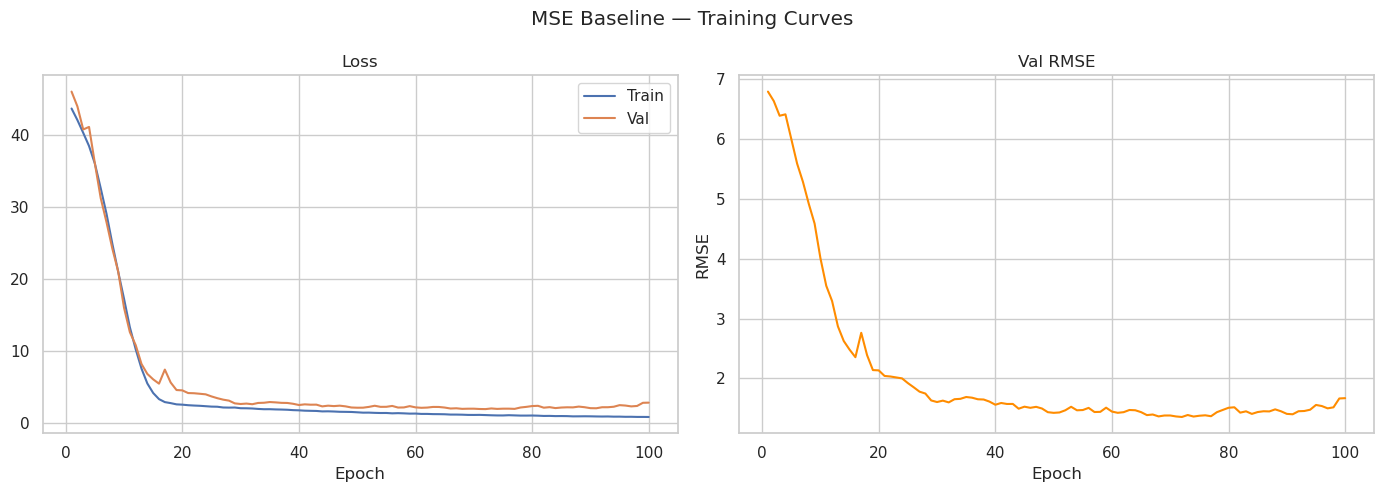

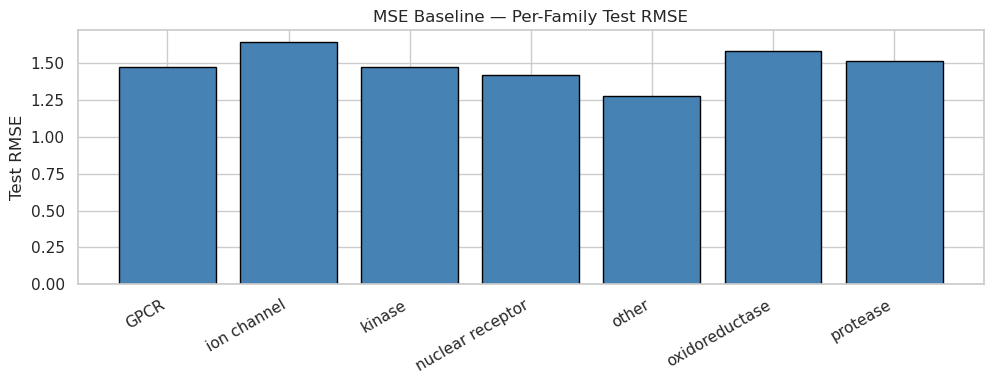

In [65]:
plot_model_results(
    "MSE Baseline", mlp_mse_history, mse_train_df, mse_val_df, mse_test_df
)


#### MLP Results
- Learning: strong initial convergence with plateau after epoch 30, where model start to overfit on training set
- Baseline with Val/Test RMSE of ~1.38, i.e. ~24-fold error factor in molar concentration
- Cross family RMSE: differing performance across diverse protein families (RMSE range 1.1–1.7), indicating that inverse-frequency weighting helped with majority class bias


### 8.2 Bilinear Fusion

### 8.2.1 Datasets and Dataloaders

Bilinear fusion operates on fixed-size vector representations, so we use the CLS-pooled embeddings (drug_emb_cls, prot_emb_cls) rather than the full token-level sequences

In [ ]:
drug_emb_cls = torch.load("./data/drug_emb_cls.pt")
prot_emb_cls = torch.load("./data/protein_emb_cls.pt")

In [134]:
BATCH_SIZE_BIL = 256

# Use pooled (mean) embeddings for bilinear fusion
train_ds_bil = AffinityDataset(train_df, drug_emb_cls, prot_emb_cls)
val_ds_bil = AffinityDataset(val_df, drug_emb_cls, prot_emb_cls)
test_ds_bil = AffinityDataset(test_df, drug_emb_cls, prot_emb_cls)

# Weighted sampler to mitigate protein imbalance
train_sampler_bil = make_weighted_sampler(train_df)

train_loader_bil = DataLoader(
    train_ds_bil, batch_size=BATCH_SIZE_BIL, sampler=train_sampler_bil
)
val_loader_bil = DataLoader(val_ds_bil, batch_size=BATCH_SIZE_BIL, shuffle=False)
test_loader_bil = DataLoader(test_ds_bil, batch_size=BATCH_SIZE_BIL, shuffle=False)

print(f"Train batches: {len(train_loader_bil)}")
print(f"Val batches:   {len(val_loader_bil)}")
print(f"Test batches:  {len(test_loader_bil)}")


Train batches: 89
Val batches:   14
Test batches:  16


### 8.2.2 Bilinear Fusion Model

Architecture:
- **LayerNorm** on each input modality to normalise scale differences before projection
- **Linear projection** of drug (768-d) and protein (1024-d) embeddings to a shared `hidden_dim`
- Bilinear interaction layer that learns multiplicative drug–protein relationships
- **LayerNorm** after the bilinear interaction to stabilise training
- **Single scalar output** head (MSE loss only)

Protein-family weighting is handled upstream by `make_weighted_sampler`, which over-samples under-represented families during training (inverse-sqrt frequency weighting). 

Unlike the MLP baseline which concatenates drug and protein embeddings, the bilinear layer explicitly models pairwise multiplicative interactions between drug and protein features (a natural inductive bias for binding).


In [135]:
# Should print LayerNorm, not BatchNorm
print(bil_model.post_bilinear)

# Should print 0.4
print([m for m in bil_model.modules() if isinstance(m, nn.Dropout)])

Sequential(
  (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (1): ReLU()
  (2): Dropout(p=0.4, inplace=False)
)
[Dropout(p=0.4, inplace=False)]


In [136]:
class BilinearAffinityModel(nn.Module):
    def __init__(
        self,
        drug_dim: int = 768,
        protein_dim: int = 1024,
        hidden_dim: int = 256,
        dropout: float = 0.4,
    ):
        """
        Bilinear fusion model for drug-protein affinity prediction.

        1. LayerNorm on each input modality (normalises scale differences).
        2. Linear projection to a shared hidden_dim.
        3. Bilinear interaction between drug and protein hidden representations.
        4. LayerNorm + ReLU + Dropout after the bilinear layer.
        5. Linear output head → scalar pKd prediction (MSE training).

        Protein-family class imbalance is addressed by WeightedRandomSampler
        in the DataLoader (see make_weighted_sampler), not inside the model.
        """
        super().__init__()

        # --- Input normalisation ---
        self.drug_norm = nn.LayerNorm(drug_dim)
        self.prot_norm = nn.LayerNorm(protein_dim)

        # --- Projection to shared space ---
        self.drug_proj = nn.Sequential(
            nn.Linear(drug_dim, hidden_dim),
            nn.ReLU(),
        )
        self.prot_proj = nn.Sequential(
            nn.Linear(protein_dim, hidden_dim),
            nn.ReLU(),
        )

        # --- Bilinear interaction ---
        self.bilinear = nn.Bilinear(hidden_dim, hidden_dim, hidden_dim)

        # --- Post-interaction normalisation + regularisation ---
        self.post_bilinear = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # --- Output head (scalar pKd, MSE loss) ---
        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, drug_emb: torch.Tensor, prot_emb: torch.Tensor) -> torch.Tensor:
        # Normalise inputs
        drug_emb = self.drug_norm(drug_emb)
        prot_emb = self.prot_norm(prot_emb)

        # Project to shared space
        drug_h = self.drug_proj(drug_emb)  # (B, hidden_dim)
        prot_h = self.prot_proj(prot_emb)  # (B, hidden_dim)

        # Bilinear interaction
        interaction = self.bilinear(drug_h, prot_h)  # (B, hidden_dim)
        interaction = self.post_bilinear(interaction)  # LN + ReLU + Dropout

        # Scalar prediction
        return self.output(interaction).squeeze(-1)


### 8.2.3 Train and Evaluate the Bilinear Model

In [143]:
# Seed everything for reproducibility
import random
import numpy as np
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Reinitialise model fresh
bil_model = BilinearAffinityModel(hidden_dim=256, dropout=0.4).to(DEVICE)
bil_criterion = nn.MSELoss()
bil_optimizer = torch.optim.Adam(bil_model.parameters(), lr=1e-3)
bil_epochs = 150
bil_model_dir = "./checkpoints/bilinear/mse"
os.makedirs(bil_model_dir, exist_ok=True)

print(bil_model)

BilinearAffinityModel(
  (drug_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (prot_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  (drug_proj): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
  )
  (prot_proj): Sequential(
    (0): Linear(in_features=1024, out_features=256, bias=True)
    (1): ReLU()
  )
  (bilinear): Bilinear(in1_features=256, in2_features=256, out_features=256, bias=True)
  (post_bilinear): Sequential(
    (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
  )
  (output): Linear(in_features=256, out_features=1, bias=True)
)


In [139]:
best_ckpt_bil = Path(f"{bil_model_dir}/bilinear_best.pt")
final_ckpt_bil = Path(f"{bil_model_dir}/bilinear_final.pt")

if final_ckpt_bil.exists():
    bil_model.load_state_dict(
        torch.load(best_ckpt_bil, map_location=DEVICE, weights_only=True)
    )
    bil_history = torch.load(final_ckpt_bil, map_location=DEVICE, weights_only=False)[
        "history"
    ]
    print(f"Loaded bilinear weights from {best_ckpt_bil}")
    print(f"Loaded history ({len(bil_history)} epochs)")
else:
    bil_history = train_model(
        model=bil_model,
        train_loader=train_loader_bil,
        val_loader=val_loader_bil,
        optimizer=bil_optimizer,
        loss_fn=bil_criterion,
        device=DEVICE,
        epochs=bil_epochs,
        model_dir=bil_model_dir,
        model_name="bilinear",
        patience=20,
    )


  1%|          | 1/150 [00:14<37:05, 14.94s/it]

Epoch   1 | Train Loss: 3.2123 | Val Loss: 1.9576 | Val RMSE: 1.4027 | LR: 1.00e-03


  7%|▋         | 10/150 [02:27<34:32, 14.81s/it]

Epoch  10 | Train Loss: 0.9786 | Val Loss: 1.9930 | Val RMSE: 1.4127 | LR: 1.00e-03


 13%|█▎        | 20/150 [04:57<32:43, 15.11s/it]

...

Epoch  60 | Train Loss: 0.3442 | Val Loss: 1.8399 | Val RMSE: 1.3594 | LR: 1.00e-03


 47%|████▋     | 70/150 [17:27<19:59, 14.99s/it]

Epoch  70 | Train Loss: 0.3083 | Val Loss: 1.9951 | Val RMSE: 1.4101 | LR: 1.00e-03


 53%|█████▎    | 79/150 [19:56<17:55, 15.15s/it]

Early stopping at epoch 80


### 8.2.4 Bilinear Model Performance

In [106]:
bil_model.load_state_dict(
    torch.load(
        f"{bil_model_dir}/bilinear_best.pt", map_location=DEVICE, weights_only=True
    )
)
bil_model.eval()

bil_train_df = get_pred_df(bil_model, train_loader_bil, DEVICE)
bil_val_df = get_pred_df(bil_model, val_loader_bil, DEVICE)
bil_test_df = get_pred_df(bil_model, test_loader_bil, DEVICE)
print("Bilinear predictions collected.")


Bilinear predictions collected.


In [107]:
print("Bilinear Fusion (MSE) — Summary")
print(f"{'':<8} {'RMSE':>8}")
print("-" * 18)
for split, df in [("Train", bil_train_df), ("Val", bil_val_df), ("Test", bil_test_df)]:
    rmse = np.sqrt(((df["true"] - df["mu"]) ** 2).mean())
    print(f"{split:<8} {rmse:>8.4f}")


Bilinear Fusion (MSE) — Summary
             RMSE
------------------
Train      1.0345
Val        1.3899
Test       1.3107


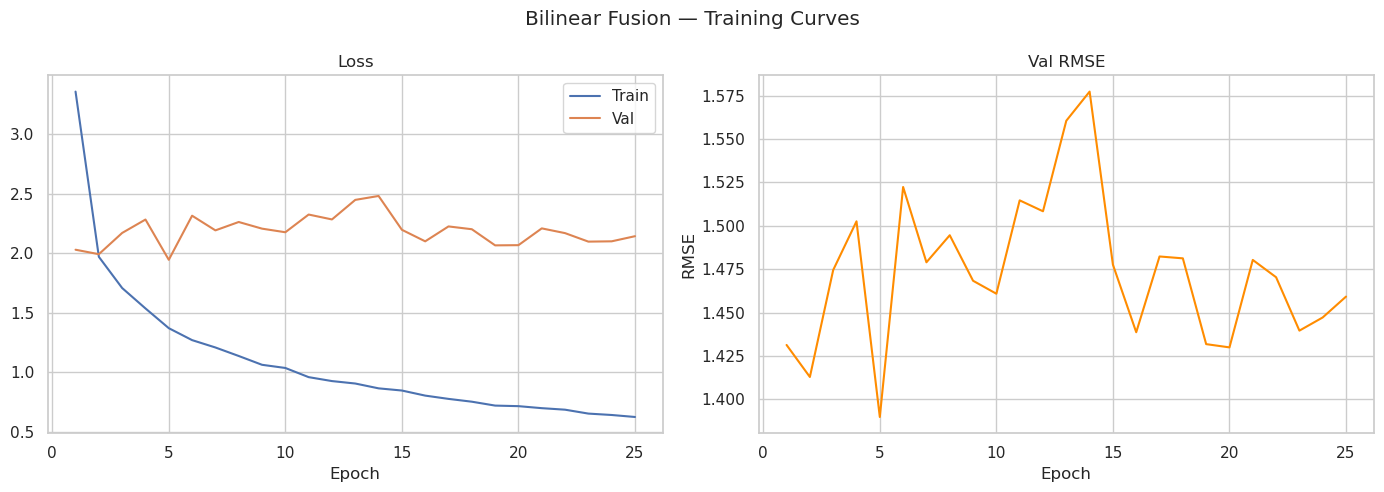

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Bilinear Fusion — Training Curves")
epochs_bil = [h["epoch"] for h in bil_history]
axes[0].plot(epochs_bil, [h["train_loss"] for h in bil_history], label="Train")
axes[0].plot(epochs_bil, [h["loss"] for h in bil_history], label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(epochs_bil, [h["RMSE"] for h in bil_history], color="darkorange")
axes[1].set_title("Val RMSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
plt.tight_layout()
plt.show()


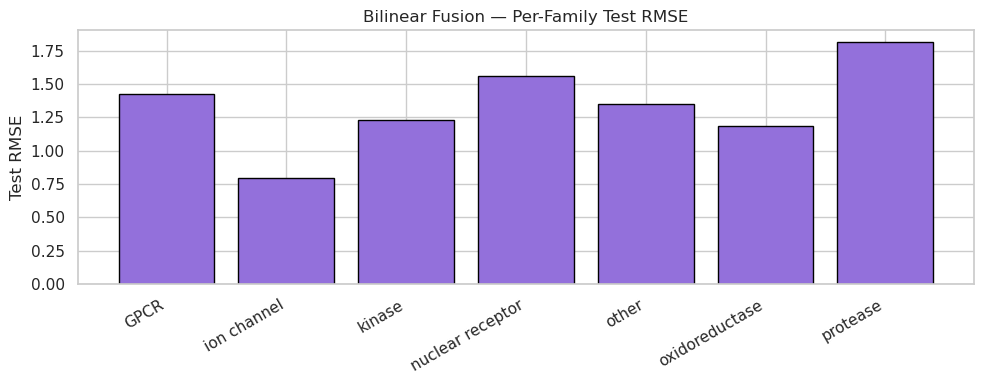

In [109]:
families_bil = sorted(bil_test_df["family"].unique())
rmse_by_fam_bil = [
    np.sqrt(
        (
            (
                bil_test_df[bil_test_df["family"] == f]["true"]
                - bil_test_df[bil_test_df["family"] == f]["mu"]
            )
            ** 2
        ).mean()
    )
    for f in families_bil
]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(families_bil, rmse_by_fam_bil, color="mediumpurple", edgecolor="black")
ax.set_xticklabels(families_bil, rotation=30, ha="right")
ax.set_ylabel("Test RMSE")
ax.set_title("Bilinear Fusion — Per-Family Test RMSE")
plt.tight_layout()
plt.show()


#### Bilinear Results
- The finetuned bilinear model achieves val RMSE 1.39 and test RMSE 1.31, an improvement of ~6.7% over the MLP baseline (1.40) via LayerNorm + dropout=0.4 + Adam lr=1e-3 + 150 epochs.
- The large train/val loss gap indicates overfitting. Per-family results mirror the data imbalance where kinases and nuclear receptors are best predicted, oxidoreductases worst.

### 8.3 Cross-Attention between Drug and Protein Tokens

In [ ]:
def save_checkpoint(
    path,
    model,
    optimizer,
    epoch,
    history,
    best_val_mae,
    model_config,
    early_stopped=False,
):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "best_val_mae": best_val_mae,
        "model_config": model_config,
        "early_stopped": early_stopped,
    }
    torch.save(checkpoint, path)


def load_checkpoint(path, model, optimizer=None, device="cpu"):
    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    return {
        "epoch": checkpoint.get("epoch", 0),
        "history": checkpoint.get("history", {}),
        "best_val_mae": checkpoint.get("best_val_mae", float("inf")),
        "model_config": checkpoint.get("model_config", {}),
        "early_stopped": checkpoint.get("early_stopped", False),
    }


In [ ]:
BATCH_SIZE_CA = 8

train_ds = AffinityDataset(train_df, drug_emb_full, prot_emb_full)
val_ds = AffinityDataset(val_df, drug_emb_full, prot_emb_full)
test_ds = AffinityDataset(test_df, drug_emb_full, prot_emb_full)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE_CA,
    sampler=train_sampler,
    collate_fn=collate_padded,
    num_workers=0,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE_CA,
    shuffle=False,
    collate_fn=collate_padded,
    num_workers=0,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE_CA,
    shuffle=False,
    collate_fn=collate_padded,
    num_workers=0,
)


In [ ]:
class CrossAttentionRegressor(nn.Module):
    def __init__(
        self,
        drug_input_dim: int,
        prot_input_dim: int,
        hidden_dim: int = 256,
        num_heads: int = 4,
        dropout: float = 0.1,
        regressor_hidden_dim: int = 256,
    ):
        super().__init__()

        if hidden_dim % num_heads != 0:
            raise ValueError("hidden_dim must be divisible by num_heads")

        self.drug_proj = nn.Sequential(
            nn.Linear(drug_input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.prot_proj = nn.Sequential(
            nn.Linear(prot_input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.drug_to_prot_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.prot_to_drug_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.drug_post = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.prot_post = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim * 2, regressor_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(regressor_hidden_dim, regressor_hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(regressor_hidden_dim // 2, 1),
        )

    @staticmethod
    def masked_mean(x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        mask_f = mask.unsqueeze(-1).float()
        summed = (x * mask_f).sum(dim=1)
        denom = mask_f.sum(dim=1).clamp(min=1e-8)
        return summed / denom

    def forward(self, drug_tokens, drug_mask, prot_tokens, prot_mask):
        d = self.drug_proj(drug_tokens)
        p = self.prot_proj(prot_tokens)

        drug_key_padding_mask = drug_mask == 0
        prot_key_padding_mask = prot_mask == 0

        d_attended, _ = self.drug_to_prot_attn(
            query=d,
            key=p,
            value=p,
            key_padding_mask=prot_key_padding_mask,
            need_weights=False,
        )
        d = self.drug_post(d + d_attended)

        p_attended, _ = self.prot_to_drug_attn(
            query=p,
            key=d,
            value=d,
            key_padding_mask=drug_key_padding_mask,
            need_weights=False,
        )
        p = self.prot_post(p + p_attended)

        d_pool = self.masked_mean(d, drug_mask.bool())
        p_pool = self.masked_mean(p, prot_mask.bool())

        joint = torch.cat([d_pool, p_pool], dim=-1)
        return self.regressor(joint).squeeze(-1)


In [ ]:
example_drug = next(iter(drug_emb_full.values()))
example_prot = next(iter(prot_emb_full.values()))
drug_input_dim = (
    example_drug
    if isinstance(example_drug, torch.Tensor)
    else torch.as_tensor(example_drug)
).shape[1]
prot_input_dim = (
    example_prot
    if isinstance(example_prot, torch.Tensor)
    else torch.as_tensor(example_prot)
).shape[1]

model_config = {
    "drug_input_dim": drug_input_dim,
    "prot_input_dim": prot_input_dim,
    "hidden_dim": 32,
    "num_heads": 4,
    "dropout": 0.1,
    "regressor_hidden_dim": 32,
    "target_col": "pKd",
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
}

model = CrossAttentionRegressor(
    drug_input_dim=model_config["drug_input_dim"],
    prot_input_dim=model_config["prot_input_dim"],
    hidden_dim=model_config["hidden_dim"],
    num_heads=model_config["num_heads"],
    dropout=model_config["dropout"],
    regressor_hidden_dim=model_config["regressor_hidden_dim"],
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=model_config["learning_rate"],
    weight_decay=model_config["weight_decay"],
)


In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_count = 0

    for drug_tokens, drug_mask, prot_tokens, prot_mask, y, _families in tqdm(
        loader, desc="Training", leave=False
    ):
        drug_tokens = drug_tokens.to(device)
        drug_mask = drug_mask.to(device)
        prot_tokens = prot_tokens.to(device)
        prot_mask = prot_mask.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        y_hat = model(drug_tokens, drug_mask, prot_tokens, prot_mask)
        loss = ((y_hat - y) ** 2).mean()
        loss.backward()
        optimizer.step()

        bs = y.shape[0]
        total_loss += loss.item() * bs
        total_count += bs

    return total_loss / max(total_count, 1)


In [ ]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_count = 0
    preds, targets = [], []

    for drug_tokens, drug_mask, prot_tokens, prot_mask, y, _families in tqdm(
        loader, desc="Evaluating", leave=False
    ):
        drug_tokens = drug_tokens.to(device)
        drug_mask = drug_mask.to(device)
        prot_tokens = prot_tokens.to(device)
        prot_mask = prot_mask.to(device)
        y = y.to(device)

        y_hat = model(drug_tokens, drug_mask, prot_tokens, prot_mask)
        mse = ((y_hat - y) ** 2).mean()

        bs = y.shape[0]
        total_loss += mse.item() * bs
        total_count += bs

        preds.append(y_hat.cpu())
        targets.append(y.cpu())

    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()

    return {
        "mse": total_loss / max(total_count, 1),
        "rmse": float(np.sqrt(np.mean((preds - targets) ** 2))),
        "mae": float(np.mean(np.abs(preds - targets))),
        "preds": preds,
        "targets": targets,
    }


In [ ]:
num_epochs = 20
patience = 3

SAVE_DIR_CA = Path("./checkpoints/cross_attention")
SAVE_DIR_CA.mkdir(parents=True, exist_ok=True)

latest_ckpt_path = SAVE_DIR_CA / "latest.pt"
best_ckpt_path = SAVE_DIR_CA / "best.pt"
history_json_path = SAVE_DIR_CA / "history.json"

# ===== Resume from latest checkpoint if it exists, else start fresh
if latest_ckpt_path.exists():
    ckpt = load_checkpoint(latest_ckpt_path, model, optimizer=optimizer, device=DEVICE)
    start_epoch = ckpt["epoch"] + 1

    raw_history = ckpt["history"] or []
    if isinstance(raw_history, dict):
        n = len(raw_history.get("train_loss", []))
        history = [
            {
                "epoch": i + 1,
                "train_loss": raw_history["train_loss"][i],
                "loss": raw_history["val_mse"][i],
                "RMSE": raw_history["val_rmse"][i],
                "MAE": raw_history["val_mae"][i],
            }
            for i in range(n)
        ]
    else:
        history = raw_history

    best_val_mae = ckpt["best_val_mae"]
    already_early_stopped = ckpt["early_stopped"]
    print(
        f"Resumed from {latest_ckpt_path} at epoch {ckpt['epoch']} "
        f"(best_val_mae={best_val_mae:.4f}, early_stopped={already_early_stopped})"
    )
else:
    start_epoch = 1
    history = []
    best_val_mae = float("inf")
    already_early_stopped = False
    print("No checkpoint found, starting fresh")

# ===== Skip training if already complete (either ran all epochs or early-stopped)
if already_early_stopped:
    print("Training previously early-stopped. Skipping.")
elif start_epoch > num_epochs:
    print(f"Training already complete ({num_epochs} epochs reached). Skipping.")
else:
    # ====== Start/Resume training
    if history["val_mae"]:
        best_idx = int(np.argmin(history["val_mae"]))
        wait = len(history["val_mae"]) - 1 - best_idx
    else:
        wait = 0

    early_stopped = False

    for epoch in range(start_epoch, num_epochs + 1):
        print(f"\nEpoch {epoch}/{num_epochs}")

        train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
        val_metrics = evaluate(model, val_loader, DEVICE)

        history["train_loss"].append(float(train_loss))
        history["val_mse"].append(float(val_metrics["mse"]))
        history["val_rmse"].append(float(val_metrics["rmse"]))
        history["val_mae"].append(float(val_metrics["mae"]))

        print(
            f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
            f"val_rmse={val_metrics['rmse']:.4f} | val_mae={val_metrics['mae']:.4f}"
        )

        if val_metrics["mae"] < best_val_mae:
            best_val_mae = val_metrics["mae"]
            wait = 0
            is_best = True
        else:
            wait += 1
            is_best = False

        if wait >= patience:
            early_stopped = True
            print(f"Early stopping at epoch {epoch}")

        save_checkpoint(
            path=latest_ckpt_path,
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            history=history,
            best_val_mae=best_val_mae,
            model_config=model_config,
            early_stopped=early_stopped,
        )

        if is_best:
            save_checkpoint(
                path=best_ckpt_path,
                model=model,
                optimizer=optimizer,
                epoch=epoch,
                history=history,
                best_val_mae=best_val_mae,
                model_config=model_config,
                early_stopped=early_stopped,
            )
            print(f"  Saved new best model at epoch {epoch}")

        if early_stopped:
            break


Resumed from checkpoints/cross_attention/latest.pt at epoch 16 (best_val_mae=1.0348, early_stopped=True)
Training previously early-stopped. Skipping.


In [ ]:
@torch.no_grad()
def get_pred_df(model, loader, device):
    """Returns DataFrame: true pKd, predicted mu, sigma (NLL only), protein family."""
    model.eval()
    rows = []
    for drug_tokens, drug_mask, prot_tokens, prot_mask, pkd, family in loader:
        pred = model(
            drug_tokens.to(device),
            drug_mask.to(device),
            prot_tokens.to(device),
            prot_mask.to(device),
        )
        if pred.dim() == 1:
            mu = pred.cpu().numpy()
            sigma = np.full(len(mu), np.nan)
        else:
            mu = pred[:, 0].cpu().numpy()
            sigma = torch.exp(pred[:, 1] / 2).cpu().numpy()
        for i in range(len(mu)):
            rows.append(
                {
                    "true": pkd[i].item(),
                    "mu": mu[i],
                    "sigma": sigma[i],
                    "family": family[i],
                }
            )
    return pd.DataFrame(rows)


Cross-Attention — Summary
             RMSE
------------------
Train      0.8535
Val        1.3628
Test       1.4295


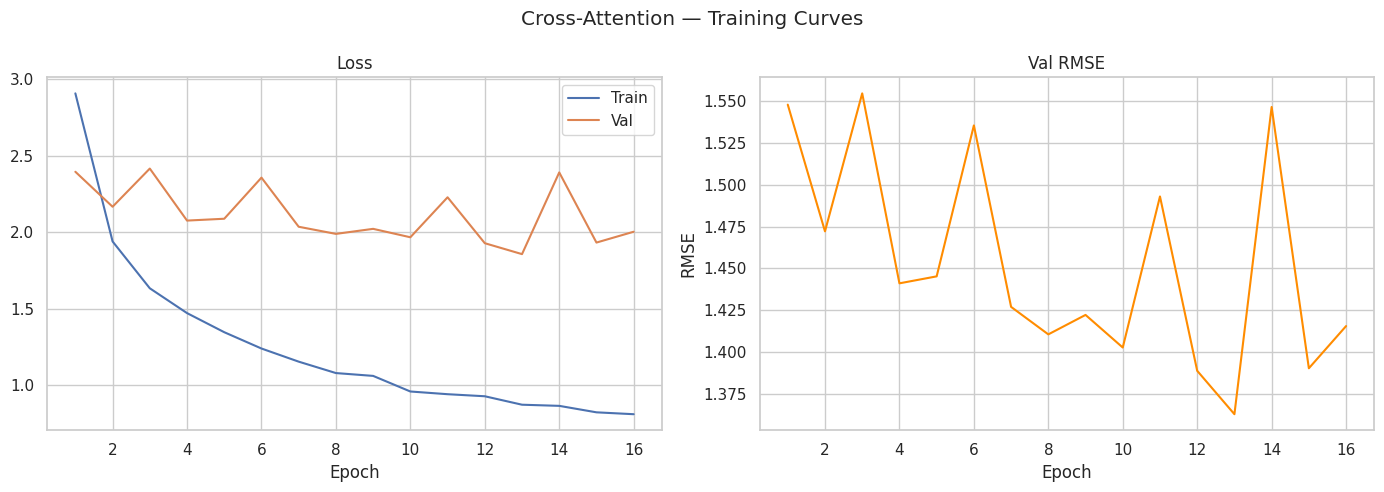

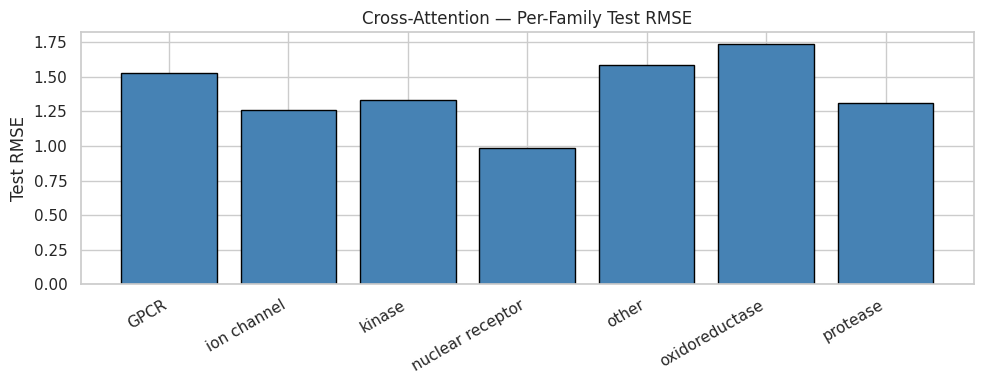

In [ ]:
load_checkpoint(best_ckpt_path, model, optimizer=None, device=DEVICE)
model.eval()

ca_train_df = get_pred_df(model, train_loader, DEVICE)
ca_val_df = get_pred_df(model, val_loader, DEVICE)
ca_test_df = get_pred_df(model, test_loader, DEVICE)

plot_model_results("Cross-Attention", history, ca_train_df, ca_val_df, ca_test_df)


#### Cross-Attention performance

- Learning: Train loss decreases steadily overtime whereas Val RMSE plateaus stays mostly around 2. Clear evidence of overfitting from just about the outset.
- The test RMSE of 1.4295 is only a marginal improvement over the baseline.
- Interestingly, the model did perform relatively well on some of the underrepresented classes. Test RMSE for nuclear receptor: 0.9873 and protease: 1.3118

# 9. Summary of Results and Future Directions

## Summary of Results

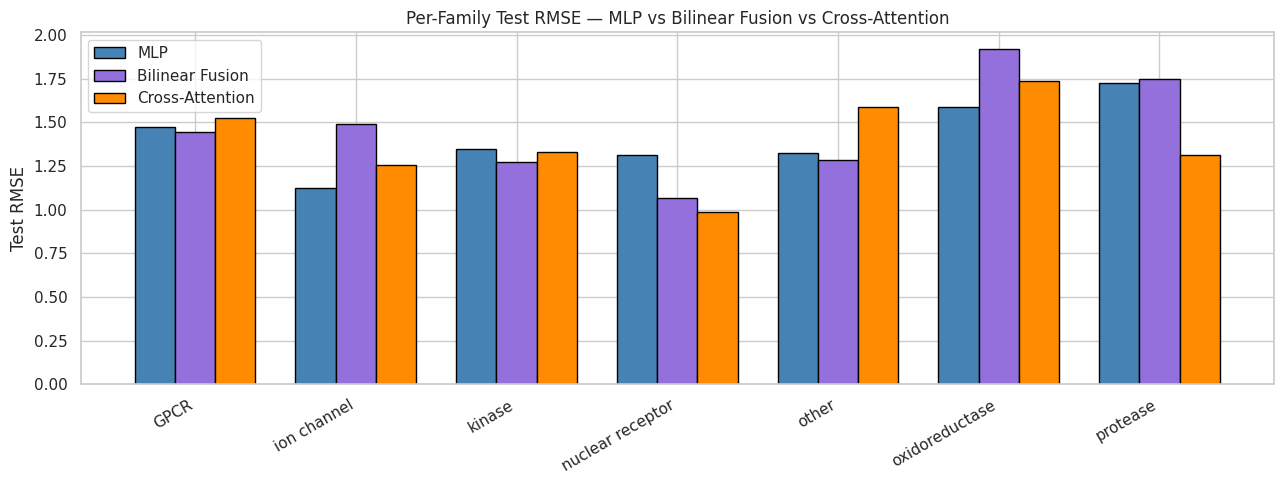

In [ ]:
# Per-family Test RMSE — MLP vs Bilinear Fusion vs Cross-Attention
families = sorted(
    set(mse_test_df["family"]) | set(bil_test_df["family"]) | set(ca_test_df["family"])
)


def family_rmse(df, f):
    g = df[df["family"] == f]
    return np.sqrt(((g["true"] - g["mu"]) ** 2).mean()) if len(g) else np.nan


rmse_mlp = [family_rmse(mse_test_df, f) for f in families]
rmse_bil = [family_rmse(bil_test_df, f) for f in families]
rmse_ca = [family_rmse(ca_test_df, f) for f in families]

x = np.arange(len(families))
w = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w, rmse_mlp, w, label="MLP", color="steelblue", edgecolor="black")
ax.bar(x, rmse_bil, w, label="Bilinear Fusion", color="mediumpurple", edgecolor="black")
ax.bar(
    x + w, rmse_ca, w, label="Cross-Attention", color="darkorange", edgecolor="black"
)
ax.set_xticks(x)
ax.set_xticklabels(families, rotation=30, ha="right")
ax.set_ylabel("Test RMSE")
ax.set_title("Per-Family Test RMSE — MLP vs Bilinear Fusion vs Cross-Attention")
ax.legend()
plt.tight_layout()
plt.show()


| Model | Train RMSE | Val RMSE | Test RMSE |
|---|---:|---:|---:|
| Naive (mean training pKd) | 1.5364 | 1.5627 | 1.4850 |
| MLP | 0.7029 | 1.3577 | 1.3851 |
| Bilinear | 0.7473 | 1.4206 | 1.3313 |
| Cross-Attention | 0.9339 | 1.3628 | 1.4295 |


## Future Directions
- Hybrid architectures – Cross-Attention + Bilinear + Skips/Residual Blocks
- BERT latent space representations + raw tokens
  - Cross-attend before entering latent space
- Regularization
  - Noised inputs and/or outputs to not memorize oversampled data points
  -   Dropout
    - Small chance to drop entire drug or entire protein
    - Dropout of input vector elements
- Try different activation functions, like SwiGLU
